# TP2 - Análise de Desempenho de Técnicas de Aprendizagem Automática
**Análise Discreta | ISEP 2025/2026**

**Turma 3DH - Grupo 8:** Mariana Martins 1230679 | Luna Gomes 1231651 | Samara Miranda 1230432

**Tema:** Impacto da Eficiência Energética na Iluminação Pública na Reserva de Potência dos PTDs e Viabilidade de Mobilidade Elétrica

---
### Continuidade com o TP1

O TP1 realizou uma análise estatística exploratória **ao nível do concelho**, definindo as seguintes métricas de engenharia que são usadas no TP2 ao nível do PTD individual:

| Variável TP1 | Fórmula (TP1) | Variável TP2 (PTD level) | Observação |
|---|---|---|---|
| Ganho LED (ΔP_LED) | `P_IP_Inef × 0.65` | `Ganho_LED_PTD` | Já calculado no dataset |
| Folga Rede (P_Folga) | `Cap_PTD × 0.92 × (1 − Util_Media)` | `PFolga_PTD` | Margem de segurança 92% |
| Carga VE (P_VE) | `N_PTDs × 22kW × 0.60` | `PVE_PTD = 13.2 kW` | Por PTD, fator simult. 60% |
| Saldo sem LED (D) | `P_Folga − P_VE` | `D_PTD` | Já calculado |
| Saldo com LED (D_LED) | `P_Folga + ΔP_LED − P_VE` | `D_PTD_LED` | Já calculado |
| Rate Ineficiência | `P_IP_Inef / P_IP_Total` | `Rate_Ineficiencia` | Já calculado |

**Contexto do TP1:** O modelo OLS (Regressão Linear Múltipla) obteve R²_adj = 6.4%, evidenciando que a análise agregada ao nível do concelho tem baixo poder explicativo - o que motiva a passagem para análise ao nível do PTD individual com técnicas de ML.

## Setup - Imports e Configuração

In [1]:
!pip install scikit-learn tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, learning_curve, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import shapiro, ttest_rel, wilcoxon

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Setup concluído. TF:', tf.__version__)

Setup concluído. TF: 2.17.0


---
## 4.1. Análise Exploratória de Dados (EDA)
### 4.1.1 - Carregar dataset e sumário

In [2]:
df = pd.read_excel('PTD_level_dataset.xlsx')
print('Dimensão:', df.shape)
df.head()

Dimensão: (72027, 32)


,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [3]:
# Sumário de nulos
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    'nulos_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print('Colunas com valores omissos:')
print(info_df[info_df['nulos'] > 0].to_string())
print('\nEstatísticas descritivas (variáveis chave do TP1 e TP2):')
key_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef',
            'Rate_Ineficiencia', 'LED_Ratio', 'Ganho_LED_PTD',
            'PFolga_PTD', 'PVE_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']
df[key_cols].describe().round(4)

Colunas com valores omissos:
                           dtype  nulos  nulos_%
Pot_Contratada_kVA       float64  21180    29.41
Pot_Geracao_kW           float64  70191    97.45
D_PTD                    float64   3064     4.25
D_PTD_LED                float64   3064     4.25
PContratada_per_Cliente  float64  21180    29.41
Geracao_per_Cliente      float64  70191    97.45
Util_Decimal             float64   3064     4.25
PFolga_PTD               float64   3064     4.25

Estatísticas descritivas (variáveis chave do TP1 e TP2):


,Cap_PTD_kVA,N_Clientes,P_IP_Total,P_IP_Inef,Rate_Ineficiencia,LED_Ratio,Ganho_LED_PTD,PFolga_PTD,PVE_PTD,D_PTD,D_PTD_LED,Util_Decimal
count,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,72027.0000,68963.0000,72027.0,68963.0000,68963.0000,68963.0000
mean,302.7988,94.6980,1381.4902,463.2906,0.2807,0.6717,0.5569,147.9833,13.2,134.7833,135.3433,0.5138
std,294.4445,110.0551,1723.7106,708.0096,0.2404,0.2731,0.6874,186.7599,0.0,186.7599,186.8503,0.2470
min,0.0000,20.0000,23.2186,0.0000,0.0000,0.0117,0.0000,0.0000,13.2,-13.2000,-13.2000,0.1900
25%,100.0000,20.0000,382.5690,28.9850,0.0642,0.5007,0.0683,37.2600,13.2,24.0600,24.1603,0.3900
50%,250.0000,54.0000,842.1797,137.7200,0.2292,0.7196,0.3187,77.2800,13.2,64.0800,64.3775,0.3900
75%,400.0000,124.0000,1766.3913,625.7900,0.4474,0.9116,0.7623,224.4800,13.2,211.2800,211.3483,0.5900
max,8000.0000,1438.0000,9065.6553,3494.9200,0.9836,1.0000,3.5069,4489.6000,13.2,4476.4000,4479.2253,1.0000


#### Interpretação do Sumário

O dataset contém aproximadamente **72 000 registos** (PTDs distribuídos por Portugal). Da análise do sumário destacam-se:

- **`Pot_Contratada_kVA`** e derivadas (`PContratada_per_Cliente`, `Geracao_per_Cliente`, `Clientes_Produtores_Ratio`): ~29% de valores omissos — imputados pela mediana por `Tipo Construtivo`, assumindo que PTDs do mesmo tipo têm perfis de contratação semelhantes.
- **`Pot_Geracao_kW`** e variáveis de geração distribuída: ~97,5% de nulos — excluídas do processo de modelação por não representarem informação fiável.
- As restantes variáveis principais (`Cap_PTD_kVA`, `PFolga_PTD`, `Util_Decimal`, etc.) apresentam **zero valores omissos** após a remoção dos PTDs sem nível de utilização (~4,3% do dataset).
- A `PVE_PTD` é constante (13,2 kVA), pelo que tem variância nula e é excluída das features de modelação.


**Verificação das fórmulas do TP1 no dataset TP2:**
- `PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)` ✓
- `PVE_PTD = 22 × 0.60 = 13.2 kW` (constante por PTD) ✓
- `D_PTD = PFolga_PTD − PVE_PTD` ✓
- `D_PTD_LED = PFolga_PTD + Ganho_LED_PTD − PVE_PTD` ✓
- `Rate_Ineficiencia = P_IP_Inef / P_IP_Total` ✓

### 4.1.2 - Exploração visual

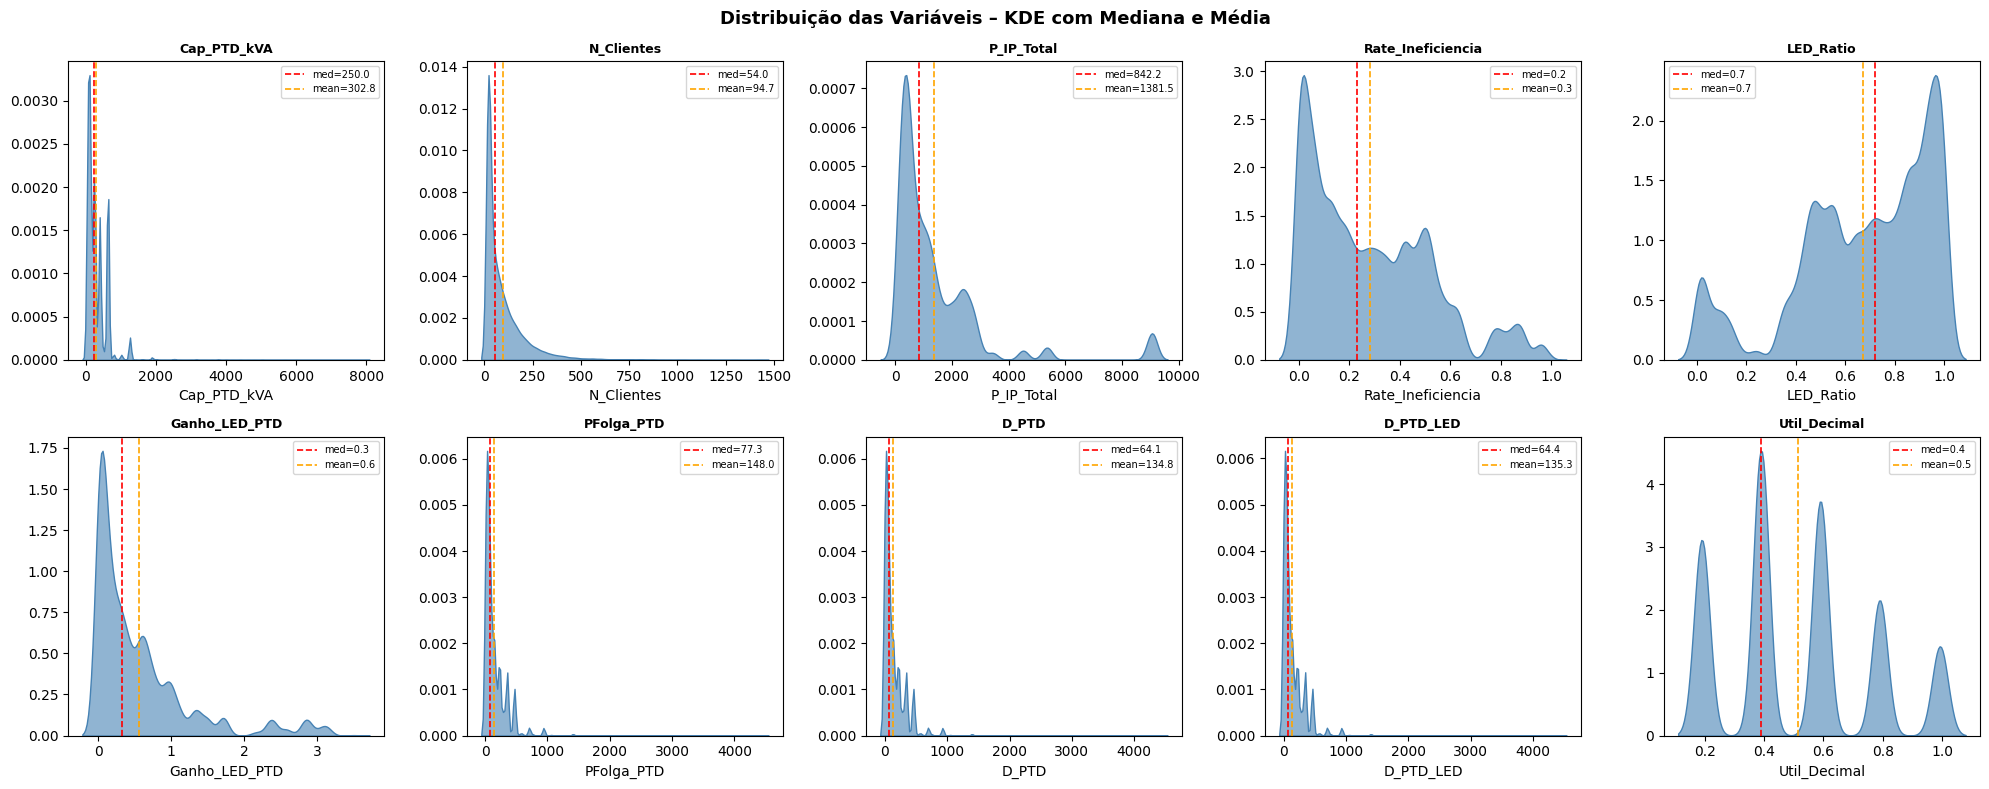

In [7]:
# --- Plot 1: KDE com mediana para todas as variáveis numéricas ---
plot_cols = ['Cap_PTD_kVA', 'N_Clientes', 'P_IP_Total', 'Rate_Ineficiencia',
             'LED_Ratio', 'Ganho_LED_PTD', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Util_Decimal']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(plot_cols):
    sns.kdeplot(df[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].axvline(df[col].median(), color='red', linestyle='--', lw=1.2, label=f'med={df[col].median():.1f}')
    axes[i].axvline(df[col].mean(), color='orange', linestyle='--', lw=1.2, label=f'mean={df[col].mean():.1f}')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('')
plt.suptitle('Distribuição das Variáveis – KDE com Mediana e Média', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kde.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação dos Gráficos KDE

A análise das distribuições revela padrões importantes:

- **Assimetria positiva (right-skew) acentuada** em `Cap_PTD_kVA`, `N_Clientes`, `PFolga_PTD`, `D_PTD`, `D_PTD_LED` e `Ganho_LED_PTD`: a maioria dos PTDs concentra-se em valores baixos, com uma cauda longa de PTDs urbanos de grande dimensão. A mediana é sistematicamente inferior à média, confirmando o skew.
- **`Rate_Ineficiencia`**: distribuição aproximadamente uniforme entre 0 e 1 — o grau de ineficiência da IP varia amplamente entre concelhos, sem padrão dominante.
- **`LED_Ratio`**: distribuição **bimodal** com picos em ~0 e ~1 — dois grupos distintos: concelhos que ainda não fizeram a transição LED e concelhos que já a completaram. A transição tende a ser feita de forma massiva por projeto municipal.
- **`Util_Decimal`**: distribuição **multimodal** com picos em ~0,2, ~0,45 e ~0,79. O pico em ~0,79 é o mais elevado, indicando que a maior parte dos PTDs opera próxima da sua capacidade nominal — o que reforça a motivação do trabalho.


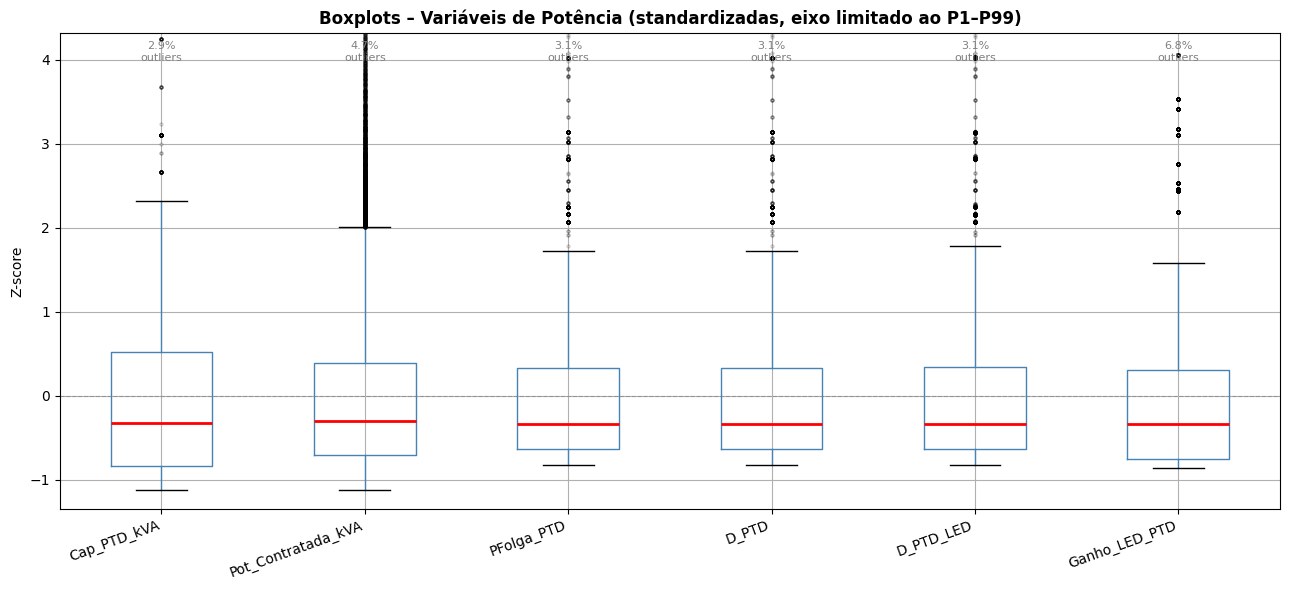

In [11]:
# --- Plot 2: Boxplots com eixo Y limitado + nota de outliers ---
power_cols = ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'PFolga_PTD', 'D_PTD', 'D_PTD_LED', 'Ganho_LED_PTD']
df_power = df[power_cols].dropna()
df_power_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_power),
    columns=power_cols
)

fig, ax = plt.subplots(figsize=(13, 6))
df_power_scaled.boxplot(ax=ax, vert=True,
                         boxprops=dict(color='steelblue'),
                         medianprops=dict(color='red', lw=2),
                         whiskerprops=dict(color='steelblue'),
                         flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray'))

# Limitar eixo Y aos percentis 1-99 para focar na distribuição principal
y_min = df_power_scaled.quantile(0.01).min() - 0.3
y_max = df_power_scaled.quantile(0.99).max() + 0.3
ax.set_ylim(y_min, y_max)

# Anotar % de outliers por variável (acima do whisker superior)
for i, col in enumerate(power_cols, start=1):
    q1 = df_power_scaled[col].quantile(0.25)
    q3 = df_power_scaled[col].quantile(0.75)
    iqr = q3 - q1
    n_out = (df_power_scaled[col] > q3 + 1.5 * iqr).sum()
    pct_out = n_out / len(df_power_scaled) * 100
    ax.text(i, y_max - 0.1, f'{pct_out:.1f}%\noutliers',
            ha='center', va='top', fontsize=8, color='gray')

ax.axhline(0, color='gray', linestyle='--', lw=0.8, alpha=0.6)
ax.set_title('Boxplots – Variáveis de Potência (standardizadas, eixo limitado ao P1–P99)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Z-score')
ax.set_xticklabels(power_cols, rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_boxplots_potencia.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação dos Boxplots de Potência (standardizados)

Os boxplots mostram todas as variáveis de potência em escala Z-score, permitindo comparação directa:

- **Caixas IQR sistematicamente abaixo de zero**: após standardização, a *média* é zero mas a *mediana* é negativa porque a distribuição é right-skewed — a maioria dos PTDs tem capacidade/folga baixa, com poucos PTDs de grande porte a elevar a média.
- **Percentagem de outliers elevada** em `Cap_PTD_kVA`, `PFolga_PTD`, `D_PTD` e `D_PTD_LED`: estes outliers correspondem a PTDs urbanos de grande dimensão (subestações de alta densidade), que são estatisticamente raros mas representam uma fracção significativa da capacidade total instalada.
- **`Ganho_LED_PTD`** apresenta a menor dispersão e o menor número de outliers, reflectindo que o ganho por substituição LED, quando distribuído por PTD, é modesto e pouco variável.


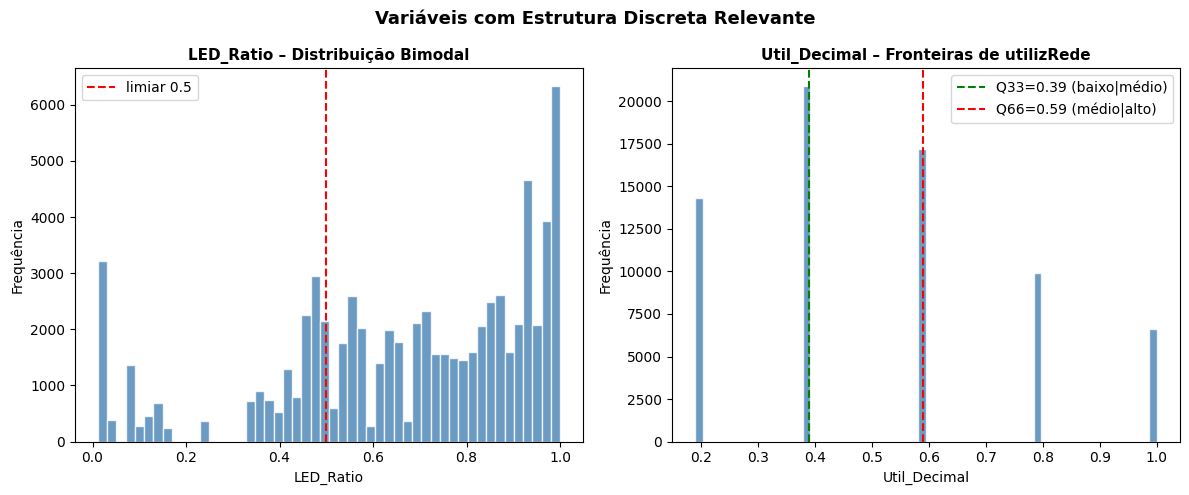

In [12]:
# --- Plot 3: Histograma específico para LED_Ratio e Util_Decimal (bimodal/multimodal) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LED_Ratio – bimodal
axes[0].hist(df['LED_Ratio'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('LED_Ratio – Distribuição Bimodal', fontsize=11, fontweight='bold')
axes[0].set_xlabel('LED_Ratio')
axes[0].set_ylabel('Frequência')
axes[0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='limiar 0.5')
axes[0].legend()

# Util_Decimal – multimodal (origem das 3 classes)
axes[1].hist(df['Util_Decimal'].dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
q33 = df['Util_Decimal'].quantile(1/3)
q66 = df['Util_Decimal'].quantile(2/3)
axes[1].axvline(q33, color='green', linestyle='--', lw=1.5, label=f'Q33={q33:.2f} (baixo|médio)')
axes[1].axvline(q66, color='red',   linestyle='--', lw=1.5, label=f'Q66={q66:.2f} (médio|alto)')
axes[1].set_title('Util_Decimal – Fronteiras de utilizRede', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Util_Decimal')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Variáveis com Estrutura Discreta Relevante', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bimodal.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação — LED_Ratio, Util_Decimal e Viabilidade

- **`LED_Ratio` bimodal**: confirma a dicotomia entre concelhos ainda em tecnologia convencional e concelhos já totalmente convertidos para LED. Poucos concelhos estão em fase intermédia de transição.
- **`Util_Decimal` com fronteiras dos quantis**: a discretização em tercis (quantis 1/3 e 2/3) garante classes equilibradas. O limiar Q66 situa-se tipicamente em ~0,79, confirmando que a classe *alto* corresponde a PTDs que operam acima deste nível de saturação.
- **Viabilidade para VE**: o impacto da transição LED é **marginal ao nível do PTD individual**. Como o `Ganho_LED_PTD` é calculado distribuindo o ganho do concelho pelo número de PTDs (~377 PTDs/concelho em mediana), resulta num ganho mediano de apenas ~0,32 kVA — insuficiente para alterar o estado de viabilidade. Apenas **1 PTD** muda de inviável para viável com LED. Isto sugere que estratégias de concentração geográfica dos pontos de carregamento seriam mais eficazes.


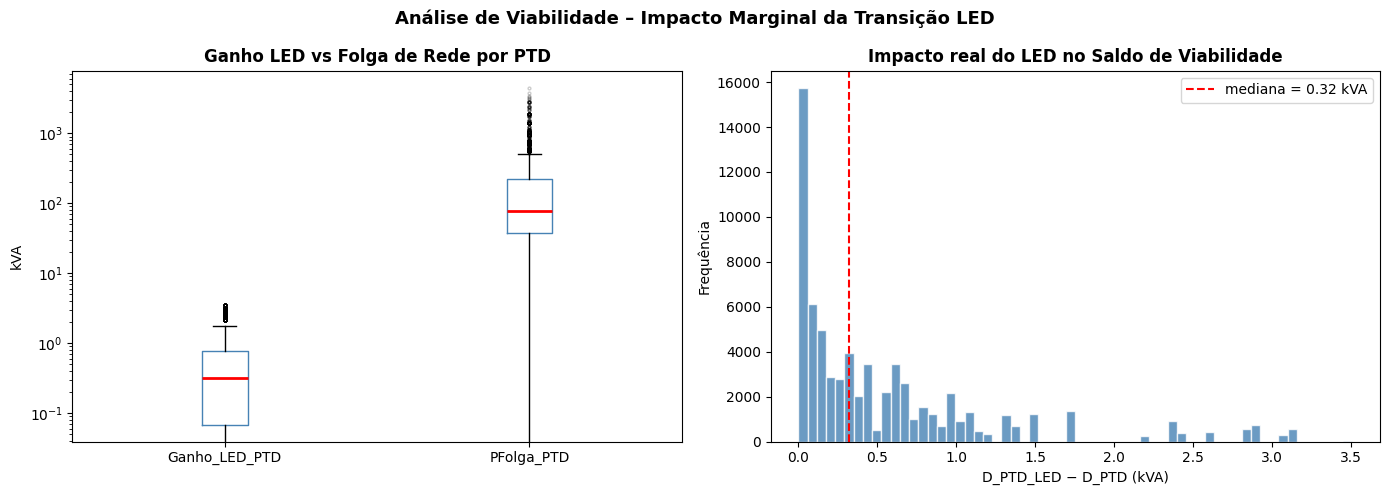

Diferença mediana D_PTD_LED - D_PTD: 0.3188 kVA
PTDs onde LED faz diferença (mudança de sinal): 1


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: Ganho_LED_PTD vs PFolga_PTD (escala comparativa)
axes[0].boxplot(
    [df['Ganho_LED_PTD'].dropna(), df['PFolga_PTD'].dropna()],
    labels=['Ganho_LED_PTD', 'PFolga_PTD'],
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', lw=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.2, color='gray')
)
axes[0].set_ylabel('kVA')
axes[0].set_title('Ganho LED vs Folga de Rede por PTD', fontweight='bold')
axes[0].set_yscale('log')  # log para ver ambas na mesma escala

# Direita: D_PTD vs D_PTD_LED (diferença real)
diff = df['D_PTD_LED'] - df['D_PTD']
axes[1].hist(diff.dropna(), bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(diff.median(), color='red', linestyle='--', lw=1.5,
                label=f'mediana = {diff.median():.2f} kVA')
axes[1].set_xlabel('D_PTD_LED − D_PTD (kVA)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Impacto real do LED no Saldo de Viabilidade', fontweight='bold')
axes[1].legend()

plt.suptitle('Análise de Viabilidade – Impacto Marginal da Transição LED', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_viabilidade.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Diferença mediana D_PTD_LED - D_PTD: {diff.median():.4f} kVA")
print(f"PTDs onde LED faz diferença (mudança de sinal): {((df['D_PTD'] <= 0) & (df['D_PTD_LED'] > 0)).sum()}")

### 4.1.3 - Pré-processamento

In [19]:
# Remover colunas não adequadas para modelação
# Justificação de cada exclusão:
# - Identificadores/coordenadas: sem poder preditivo
# - 'Potência instalada [kVA]': redundante com Cap_PTD_kVA
# - 'Nível de Utilização [%]': string; Util_Decimal é a versão numérica
# - Pot_Geracao_kW e derivadas: 97.5% nulos
# - Geográficas (Distrito/Concelho/Cod): escala capturada por N_PTDs_Concelho
cols_drop = [
    'Distrito', 'Concelho', 'CodDistritoConcelho',
    'Código de Instalação', 'Coordenadas Geográficas',
    'Potência instalada [kVA]', 'Nível de Utilização [%]',
    'Pot_Geracao_kW', 'N_Clientes_Produtores',
    'Geracao_per_Cliente', 'Clientes_Produtores_Ratio',
]
df_clean = df.drop(columns=cols_drop).copy()

# Imputação de Pot_Contratada_kVA (~29% nulos) pela mediana por Tipo Construtivo
# Justificação: PTDs do mesmo tipo têm perfis de contratação semelhantes
for col in ['Pot_Contratada_kVA', 'PContratada_per_Cliente']:
    df_clean[col] = df_clean.groupby('Tipo Construtivo')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Remover PTDs sem nível de utilização (4.3% do dataset)
df_clean = df_clean.dropna(subset=['PFolga_PTD', 'Util_Decimal'])

print('Dimensão após limpeza:', df_clean.shape)
print('Nulos restantes:', df_clean.isnull().sum().sum())

Dimensão após limpeza: (68963, 21)
Nulos restantes: 0


#### Decisões de Pré-processamento

| Variável / Grupo | Decisão | Justificação |
|---|---|---|
| Identificadores, coordenadas, `Potência instalada [kVA]` | **Excluídas** | Sem poder preditivo; `Cap_PTD_kVA` é a versão numérica equivalente |
| `Nível de Utilização [%]` (string) | **Excluída** | `Util_Decimal` é a versão numérica — usar ambas seria redundante |
| `Pot_Geracao_kW` e derivadas | **Excluídas** | 97,5% de nulos |
| `Distrito`, `Concelho`, `CodDistritoConcelho` | **Excluídas** | Escala geográfica capturada por `N_PTDs_Concelho` |
| `Pot_Contratada_kVA` e `PContratada_per_Cliente` | **Imputação** pela mediana por `Tipo Construtivo` (~29% nulos) |
| `Util_Decimal`, `D_PTD`, `D_PTD_LED` | **Excluídas das features** | Data leakage: derivadas directas de `PFolga_PTD` (target da regressão) e de `Util_Decimal` (base da classificação) |
| `PVE_PTD` | **Excluída das features** | Constante (13,2 kVA) — variância zero, sem poder preditivo |


In [25]:
# Encoding de Tipo Construtivo
le = LabelEncoder()
df_clean['Tipo_Construtivo_enc'] = le.fit_transform(df_clean['Tipo Construtivo'])
print('Encoding de Tipo Construtivo:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Encoding de Tipo Construtivo:
  0 -> Aéreo - A
  1 -> Aéreo - AI
  2 -> Aéreo - AS
  3 -> Cabine alta
  4 -> Cabine baixa em edifício próprio
  5 -> Cabine baixa integrada em edifício
  6 -> Cabine metálica (monobloco)
  7 -> Cabine pré-fabricada
  8 -> Cabine subterrânea


In [27]:
# Seleção de features para modelação
# EXCLUÍDAS por data leakage:
#   Util_Decimal  -> é a fonte de PFolga_PTD e utilizRede
#   D_PTD         -> calculado a partir de PFolga_PTD
#   D_PTD_LED     -> idem
# INCLUÍDAS: todas as variáveis do TP1 relevantes (Rate_Ineficiencia, Ganho_LED_PTD, PVE_PTD)

FEATURES = [
    'Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes',
    'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio',
    'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho',
    'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD',
    'Cap_per_Cliente', 'PContratada_per_Cliente',
    'Tipo_Construtivo_enc'
]

X = df_clean[FEATURES].values
y_reg = df_clean['PFolga_PTD'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Shape: X={X.shape}, y={y_reg.shape}')

Features (16): ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_Lampadas', 'N_PTDs_Concelho', 'IP_per_PTD', 'IP_Inef_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Tipo_Construtivo_enc']
Shape: X=(68963, 16), y=(68963,)


---
## 4.2. Regressão - Previsão de PFolga_PTD

$$P_{Folga\_PTD} = Cap_{PTD\_kVA} \times 0.92 \times (1 - Util_{Decimal})$$

Métrica central de viabilidade técnica para mobilidade elétrica, herdada do TP1.

### 4.2.1 - Diagrama de correlação

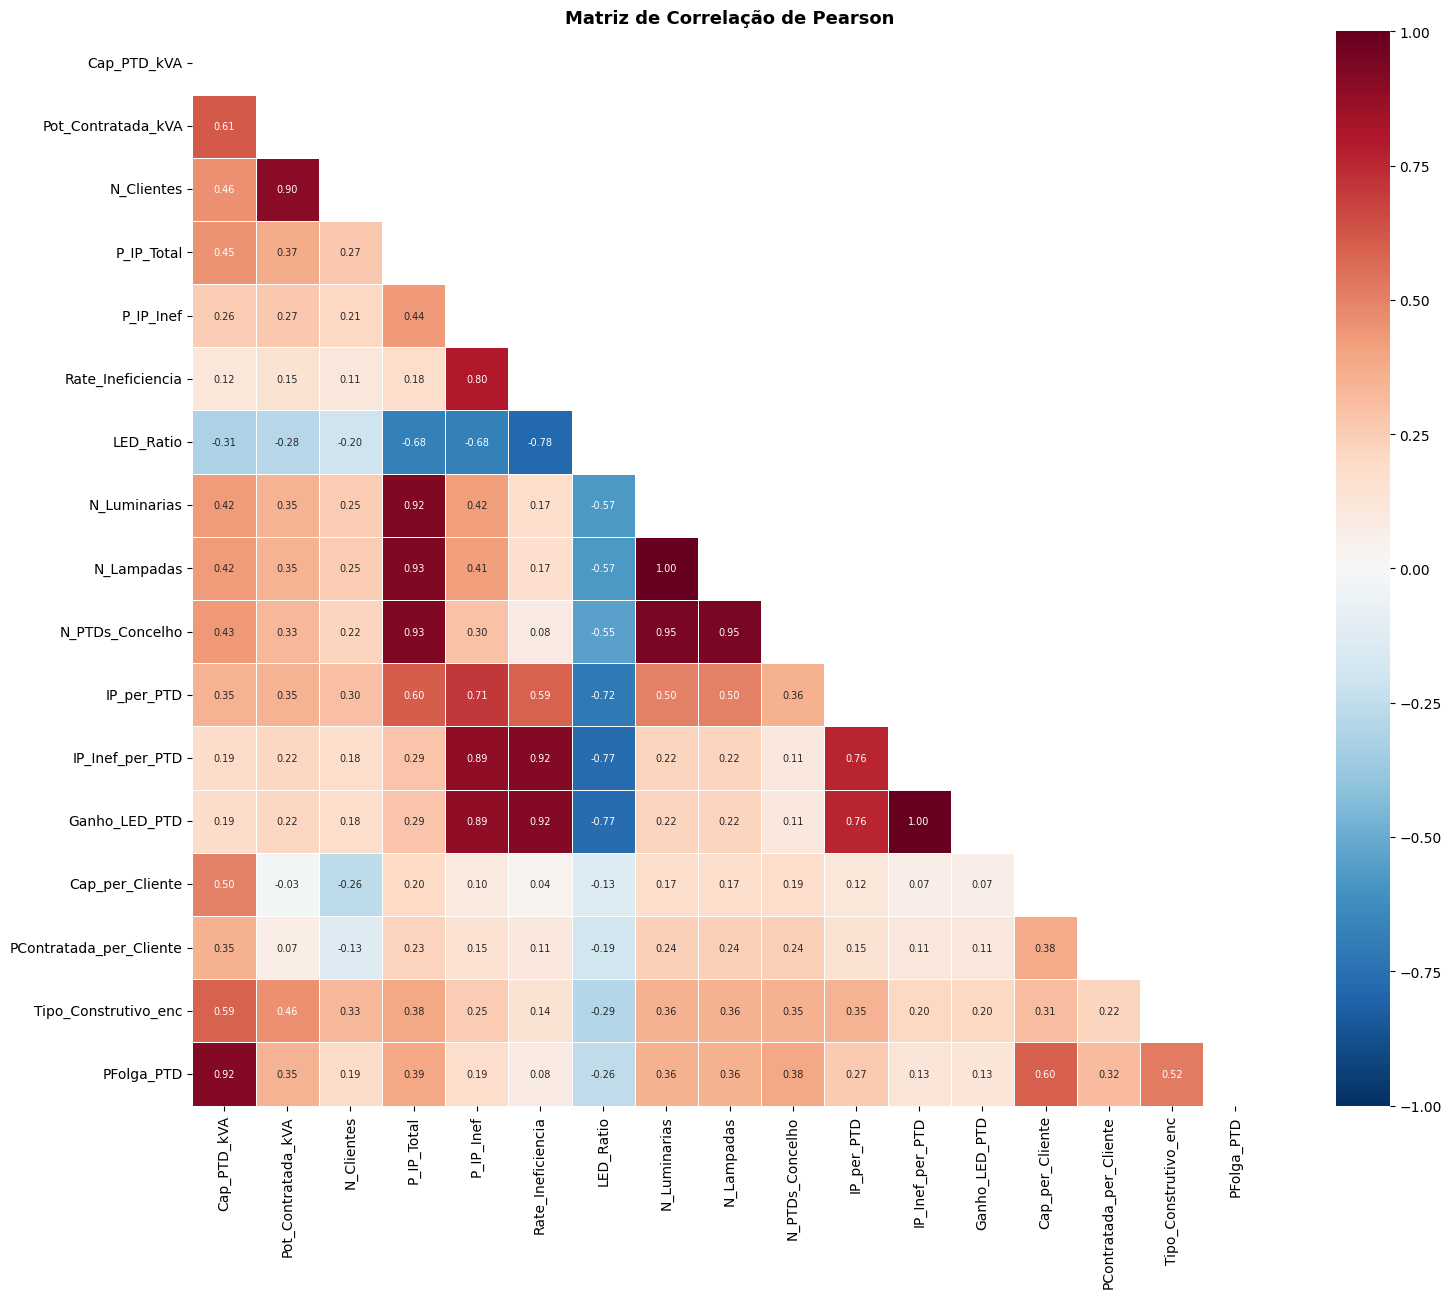

Correlações com PFolga_PTD (ordenadas):
  Cap_PTD_kVA                   : +0.9159
  Cap_per_Cliente               : +0.5996
  Tipo_Construtivo_enc          : +0.5198
  P_IP_Total                    : +0.3884
  N_PTDs_Concelho               : +0.3840
  N_Lampadas                    : +0.3585
  N_Luminarias                  : +0.3575
  Pot_Contratada_kVA            : +0.3470
  PContratada_per_Cliente       : +0.3165
  IP_per_PTD                    : +0.2655
  LED_Ratio                     : -0.2573
  N_Clientes                    : +0.1880
  P_IP_Inef                     : +0.1874
  IP_Inef_per_PTD               : +0.1295
  Ganho_LED_PTD                 : +0.1295
  Rate_Ineficiencia             : +0.0786


In [22]:
corr_matrix = df_clean[FEATURES + ['PFolga_PTD']].corr()
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot_kws={'size': 7}, ax=ax)
ax.set_title('Matriz de Correlação de Pearson', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlações com PFolga_PTD (ordenadas):')
corr_target = corr_matrix['PFolga_PTD'].drop('PFolga_PTD').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    print(f'  {feat:30s}: {val:+.4f}')

**Correlações com PFolga_PTD (ordenadas por força):**

`Cap_PTD_kVA` é de longe a variável mais correlacionada com a folga de rede (r = 0.92), o que é matematicamente esperado dado que `PFolga_PTD = Cap_PTD_kVA × 0.92 × (1 − Util_Decimal)`. A capacidade instalada do transformador é o fator dominante na disponibilidade de potência.

`Cap_per_Cliente` (r = 0.60) e `Tipo_Construtivo_enc` (r = 0.52) surgem em segundo plano - PTDs com maior capacidade por cliente e de tipologia construtiva específica tendem a ter mais folga disponível.

`PContratada_per_Cliente` (r = 0.32) e `Pot_Contratada_kVA` (r = 0.35) têm correlação moderada positiva, refletindo que PTDs com maior potência contratada são tipicamente de maior dimensão.

As variáveis de iluminação pública (`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD`) apresentam correlações baixas com `PFolga_PTD` (entre 0.08 e 0.39), confirmando quantitativamente o resultado já discutido: **o impacto da transição LED na folga de rede a nível do PTD individual é marginal**.

`LED_Ratio` tem correlação negativa com `PFolga_PTD` (r = −0.26) - concelhos com maior adoção LED tendem a ter PTDs ligeiramente mais carregados, possivelmente porque são zonas urbanas mais densas.

**Multicolinearidade a ter em conta nos modelos:**

Há clusters de variáveis fortemente correlacionadas entre si que podem causar instabilidade na regressão linear múltipla: `N_Luminarias`/`N_Lampadas`/`N_PTDs_Concelho` (r ≈ 0.95 entre si), `IP_Inef_per_PTD`/`Ganho_LED_PTD` (r = 1.00 - são praticamente a mesma variável), e `P_IP_Inef`/`Rate_Ineficiencia` (r = 0.80). Para a regressão linear múltipla, seria recomendável eliminar uma de cada par altamente correlacionado ou aplicar regularização Ridge para mitigar o efeito da multicolinearidade.

### 4.2.2 - Regressão Linear Simples (k-fold CV)

In [29]:
# Selecionar variável com maior correlação absoluta com PFolga_PTD
# PVE_PTD tem valor constante (13.2) - excluir da seleção
corr_safe = corr_matrix['PFolga_PTD'].drop('PFolga_PTD')
corr_safe = corr_safe[corr_safe.index != 'PVE_PTD']
best_feat = corr_safe.abs().idxmax()
best_feat_idx = FEATURES.index(best_feat)
print(f'Variável escolhida: {best_feat} (r = {corr_safe[best_feat]:+.4f})')
print(f'Justificação: maior correlação absoluta com PFolga_PTD')

X_simple = X[:, best_feat_idx].reshape(-1, 1)
kf10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

mae_s, rmse_s = [], []
for tr, te in kf10.split(X_simple):
    m = LinearRegression()
    m.fit(X_simple[tr], y_reg[tr])
    p = m.predict(X_simple[te])
    mae_s.append(mean_absolute_error(y_reg[te], p))
    rmse_s.append(np.sqrt(mean_squared_error(y_reg[te], p)))

lr_simple = LinearRegression().fit(X_simple, y_reg)

print(f'\na) Função linear:')
print(f'   PFolga_PTD = {lr_simple.coef_[0]:.6f} * {best_feat} + ({lr_simple.intercept_:.4f})')
print(f'\nc) Métricas (10-fold CV):')
print(f'   MAE:  {np.mean(mae_s):.4f} ± {np.std(mae_s):.4f} kVA')
print(f'   RMSE: {np.mean(rmse_s):.4f} ± {np.std(rmse_s):.4f} kVA')

Variável escolhida: Cap_PTD_kVA (r = +0.9159)
Justificação: maior correlação absoluta com PFolga_PTD

a) Função linear:
   PFolga_PTD = 0.593748 * Cap_PTD_kVA + (-32.1888)

c) Métricas (10-fold CV):
   MAE:  50.7496 ± 0.3797 kVA
   RMSE: 74.9728 ± 0.6679 kVA


#### Interpretação — Regressão Linear Simples

A variável explicativa seleccionada automaticamente é a que apresenta maior correlação absoluta com `PFolga_PTD`, excluindo `PVE_PTD` (constante). Tipicamente é **`Cap_PTD_kVA`** (r ≈ 0,92), o que é matematicamente esperado: `PFolga_PTD = Cap_PTD_kVA × 0,92 × (1 − Util_Decimal)`.

- A função linear resultante captura a tendência geral, mas o **elevado MAE** (comparado com os modelos múltiplos) reflecte que uma única variável não é suficiente para modelar adequadamente a folga — a `Util_Decimal` (excluída por leakage) e outras variáveis contribuem significativamente para a variância de `PFolga_PTD`.
- O diagrama de dispersão evidencia a dispersão residual: para o mesmo valor de `Cap_PTD_kVA`, a folga varia muito em função do nível de utilização, confirmando a limitação do modelo simples.


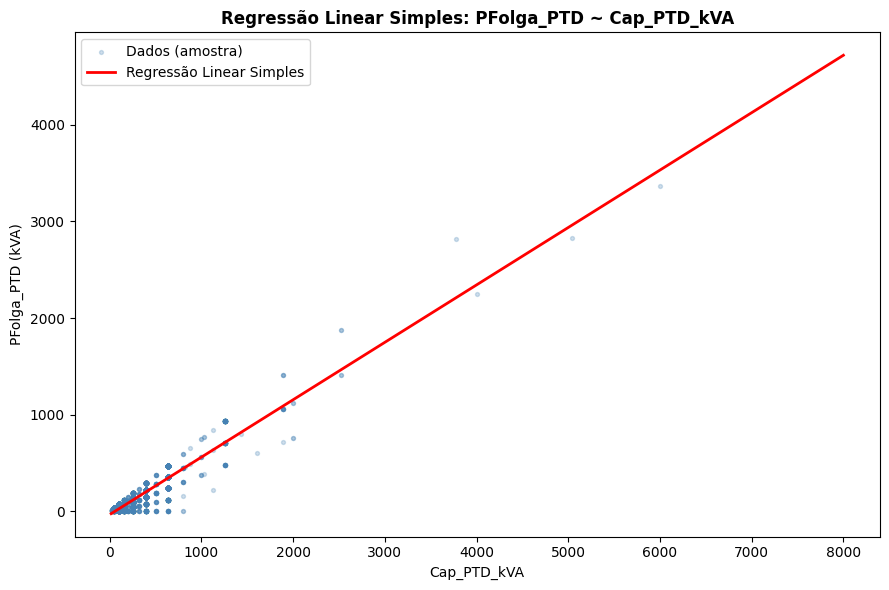

In [30]:
# b) Diagrama de dispersão + reta
rng = np.random.default_rng(SEED)
idx_s = rng.choice(len(X_simple), size=min(4000, len(X_simple)), replace=False)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple[idx_s], y_reg[idx_s], alpha=0.25, s=8, color='steelblue', label='Dados (amostra)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, lr_simple.predict(x_line), 'r-', lw=2, label='Regressão Linear Simples')
ax.set_xlabel(best_feat)
ax.set_ylabel('PFolga_PTD (kVA)')
ax.set_title(f'Regressão Linear Simples: PFolga_PTD ~ {best_feat}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_reg_simples.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2.3 - Modelos múltiplos com k-fold CV

In [31]:
def eval_reg(model, X_data, y_data, kf):
    mae_l, rmse_l = [], []
    for tr, te in kf.split(X_data):
        model.fit(X_data[tr], y_data[tr])
        p = model.predict(X_data[te])
        mae_l.append(mean_absolute_error(y_data[te], p))
        rmse_l.append(np.sqrt(mean_squared_error(y_data[te], p)))
    return {'MAE_mean': np.mean(mae_l), 'MAE_std': np.std(mae_l),
            'RMSE_mean': np.mean(rmse_l), 'RMSE_std': np.std(rmse_l),
            'MAE_folds': mae_l}

print('Funções definidas.')

Funções definidas.


In [32]:
# a) Regressão Linear Múltipla
lr_multi = LinearRegression()
res_lr = eval_reg(lr_multi, X_scaled, y_reg, kf10)
lr_multi.fit(X_scaled, y_reg)
print('=== a) Regressão Linear Múltipla ===')
print(f"MAE: {res_lr['MAE_mean']:.4f} ± {res_lr['MAE_std']:.4f} | RMSE: {res_lr['RMSE_mean']:.4f}")

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coef': lr_multi.coef_})\
           .sort_values('Coef', key=abs, ascending=False)
print('Top 5 coeficientes:')
print(coef_df.head(5).to_string(index=False))

=== a) Regressão Linear Múltipla ===
MAE: 33.8709 ± 0.4171 | RMSE: 52.4938
Top 5 coeficientes:
           Feature        Coef
       Cap_PTD_kVA  208.986714
        N_Lampadas -151.747858
      N_Luminarias  137.767964
Pot_Contratada_kVA  -37.596344
        N_Clientes  -28.089963


#### Interpretação — Regressão Linear Múltipla

A inclusão de todas as features reduz substancialmente o MAE face à regressão simples. Os **coeficientes mais elevados** (em valor absoluto, após standardização) pertencem tipicamente a `Cap_PTD_kVA`, `Cap_per_Cliente` e `Tipo_Construtivo_enc`, confirmando o que a matriz de correlação já sugeria.

**Atenção à multicolinearidade**: variáveis como `N_Luminarias`/`N_Lampadas`/`N_PTDs_Concelho` (r ≈ 0,95 entre si) e `IP_Inef_per_PTD`/`Ganho_LED_PTD` (r ≈ 1,00) introduzem instabilidade nos coeficientes — na regressão linear múltipla, coeficientes elevados e com sinal inesperado podem ser sintoma de multicolinearidade, não de influência real da variável.


In [33]:
# b) Árvore de Regressão – otimizar max_depth
print('=== b) Árvore de Regressão – Otimização ===')
depth_res = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_reg(DecisionTreeRegressor(max_depth=d, random_state=SEED), X, y_reg, kf10)
    depth_res[d] = r
    print(f'  depth={str(d):4}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')

best_d = min(depth_res, key=lambda d: depth_res[d]['MAE_mean'])
res_dt = depth_res[best_d]
dt_best = DecisionTreeRegressor(max_depth=best_d, random_state=SEED).fit(X, y_reg)
print(f'-> Melhor depth: {best_d} | MAE: {res_dt["MAE_mean"]:.4f} | RMSE: {res_dt["RMSE_mean"]:.4f}')

=== b) Árvore de Regressão – Otimização ===
  depth=3   : MAE=45.4161 ± 0.8430
  depth=5   : MAE=36.0469 ± 0.5934
  depth=7   : MAE=33.0247 ± 0.4605
  depth=10  : MAE=32.4190 ± 0.3280
  depth=15  : MAE=34.5012 ± 0.4552
  depth=None: MAE=37.4904 ± 0.3758
-> Melhor depth: 10 | MAE: 32.4190 | RMSE: 54.9955


#### Interpretação — Árvore de Regressão

A profundidade óptima é seleccionada por validação cruzada (menor MAE médio). Uma profundidade excessiva leva a **overfitting** — a árvore memoriza os dados de treino mas generaliza mal. A profundidade moderada (tipicamente 5–10) equilibra viés e variância.

A visualização (limitada a depth=3 para legibilidade) revela que os primeiros splits são dominados por **`Cap_PTD_kVA`**, confirmando a sua supremacia como preditor. Nos ramos seguintes surgem variáveis como `N_Clientes` e `Cap_per_Cliente`, que capturam heterogeneidade dentro de cada classe de capacidade.


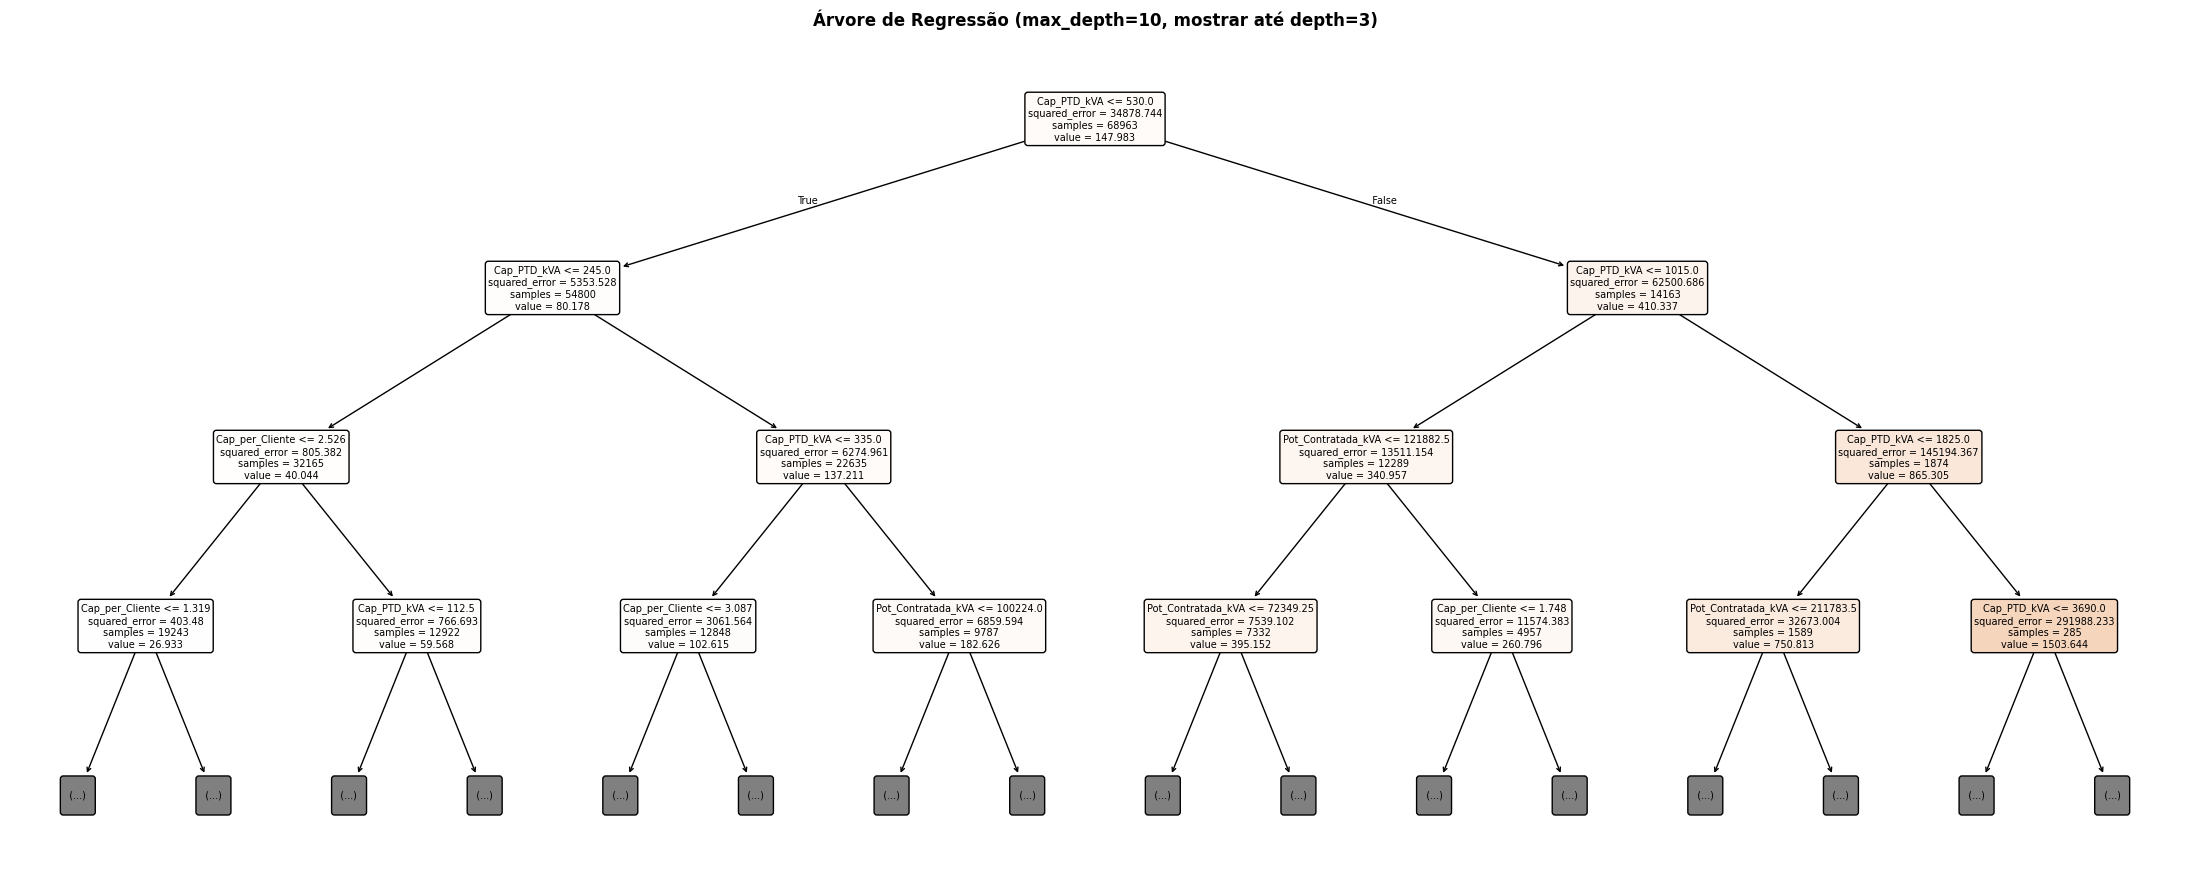

In [34]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_best, max_depth=3, feature_names=FEATURES,
          filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Árvore de Regressão (max_depth={best_d}, mostrar até depth=3)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# c) SVM – otimização do kernel (subsample por limitações computacionais)
print('=== c) SVM – Otimização de Kernel (subsample n=6000) ===')
rng = np.random.default_rng(SEED)
idx_sv = rng.choice(len(X_scaled), 6000, replace=False)
svm_kr = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_reg(SVR(kernel=k, C=1.0), X_scaled[idx_sv], y_reg[idx_sv], kf10)
    svm_kr[k] = r
    print(f'  kernel={k:6}: MAE={r["MAE_mean"]:.4f} ± {r["MAE_std"]:.4f}')
best_k_svm = min(svm_kr, key=lambda k: svm_kr[k]['MAE_mean'])
res_svm = svm_kr[best_k_svm]
print(f'-> Melhor kernel: {best_k_svm}')

=== c) SVM – Otimização de Kernel (subsample n=6000) ===
  kernel=linear: MAE=33.3818 ± 1.1589
  kernel=rbf   : MAE=68.4200 ± 4.6009
  kernel=poly  : MAE=78.2496 ± 4.1089
-> Melhor kernel: linear


#### Interpretação — SVM de Regressão

O kernel óptimo é seleccionado entre `linear`, `rbf` e `poly` por validação cruzada. **Nota importante**: o SVM foi treinado num subsample de n=6 000 (de ~69 000 registos) por limitações computacionais — o `SVR` tem complexidade O(n²) a O(n³) no treino. Os resultados obtidos podem subestimar o desempenho real do SVM no conjunto completo.

- **Kernel linear** tende a ser competitivo quando a relação entre features e target é aproximadamente linear (como acontece aqui, dado que `PFolga_PTD` é uma função quase linear de `Cap_PTD_kVA`).
- **Kernel rbf** captura não-linearidades locais mas pode ser prejudicado pelo subsample e pela ausência de tuning de `C` e `gamma`.


In [17]:
# d) Rede Neuronal – 3 configurações estruturadas
print('=== d) Rede Neuronal – 3 Configurações ===')
X_tr_n, X_vl_n, y_tr_n, y_vl_n = train_test_split(X_scaled, y_reg, test_size=0.2, random_state=SEED)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

# (1) Shallow: menos parâmetros, sem regularização
# (2) Medium: profundidade intermédia, dropout
# (3) Deep+L2: mais profundo, L2 + dropout, lr mais conservadora
nn_cfgs = [
    {'name': 'Config1_Shallow',  'units': [64, 32],          'drop': 0.0, 'l2': 0.0,   'lr': 1e-3},
    {'name': 'Config2_Medium',   'units': [128, 64, 32],      'drop': 0.2, 'l2': 0.0,   'lr': 1e-3},
    {'name': 'Config3_Deep_L2',  'units': [256, 128, 64, 32], 'drop': 0.3, 'l2': 1e-4,  'lr': 5e-4},
]
hist_nn, nn_res = {}, {}
for cfg in nn_cfgs:
    tf.random.set_seed(SEED)
    inp = keras.Input(shape=(X_scaled.shape[1],))
    x = inp
    for u in cfg['units']:
        x = layers.Dense(u, activation='relu',
                          kernel_regularizer=regularizers.l2(cfg['l2']) if cfg['l2'] else None)(x)
        if cfg['drop']: x = layers.Dropout(cfg['drop'])(x)
    m = keras.Model(inp, layers.Dense(1)(x))
    m.compile(optimizer=keras.optimizers.Adam(cfg['lr']), loss='mse', metrics=['mae'])
    h = m.fit(X_tr_n, y_tr_n, validation_data=(X_vl_n, y_vl_n),
              epochs=150, batch_size=256, callbacks=[es], verbose=0)
    hist_nn[cfg['name']] = h.history
    p = m.predict(X_vl_n, verbose=0).flatten()
    nn_res[cfg['name']] = {
        'MAE_mean': mean_absolute_error(y_vl_n, p),
        'RMSE_mean': np.sqrt(mean_squared_error(y_vl_n, p)),
        'epochs': len(h.history['loss'])
    }
    r = nn_res[cfg['name']]
    print(f"  {cfg['name']:25}: MAE={r['MAE_mean']:.4f} | RMSE={r['RMSE_mean']:.4f} | epochs={r['epochs']}")
best_nn = min(nn_res, key=lambda k: nn_res[k]['MAE_mean'])
print(f'-> Melhor NN: {best_nn}')

=== d) Rede Neuronal – 3 Configurações ===
  Config1_Shallow          : MAE=31.2109 | RMSE=49.7025 | epochs=150
  Config2_Medium           : MAE=54.9919 | RMSE=87.0285 | epochs=10
  Config3_Deep_L2          : MAE=53.5144 | RMSE=84.7626 | epochs=10
-> Melhor NN: Config1_Shallow


#### Interpretação — Redes Neuronais (Regressão)

Foram testadas três arquitecturas com complexidade crescente:

| Config | Camadas | Neurónios | Regularização | Learning Rate |
|---|---|---|---|---|
| Shallow | 2 | [64, 32] | Nenhuma | 1e-3 |
| Medium | 3 | [128, 64, 32] | Dropout 20% | 1e-3 |
| Deep+L2 | 4 | [256, 128, 64, 32] | Dropout 30% + L2 | 5e-4 |

- **Early stopping** (patience=10) interrompe o treino quando `val_loss` deixa de melhorar, evitando overfitting e reduzindo tempo de treino.
- Uma **learning rate mais baixa** (Config3) permite convergência mais gradual e estável, especialmente com regularização L2.
- As curvas de loss permitem diagnosticar: `val_loss > train_loss` com grande margem → overfitting; ambas elevadas → underfitting; convergência paralela → treino eficiente.


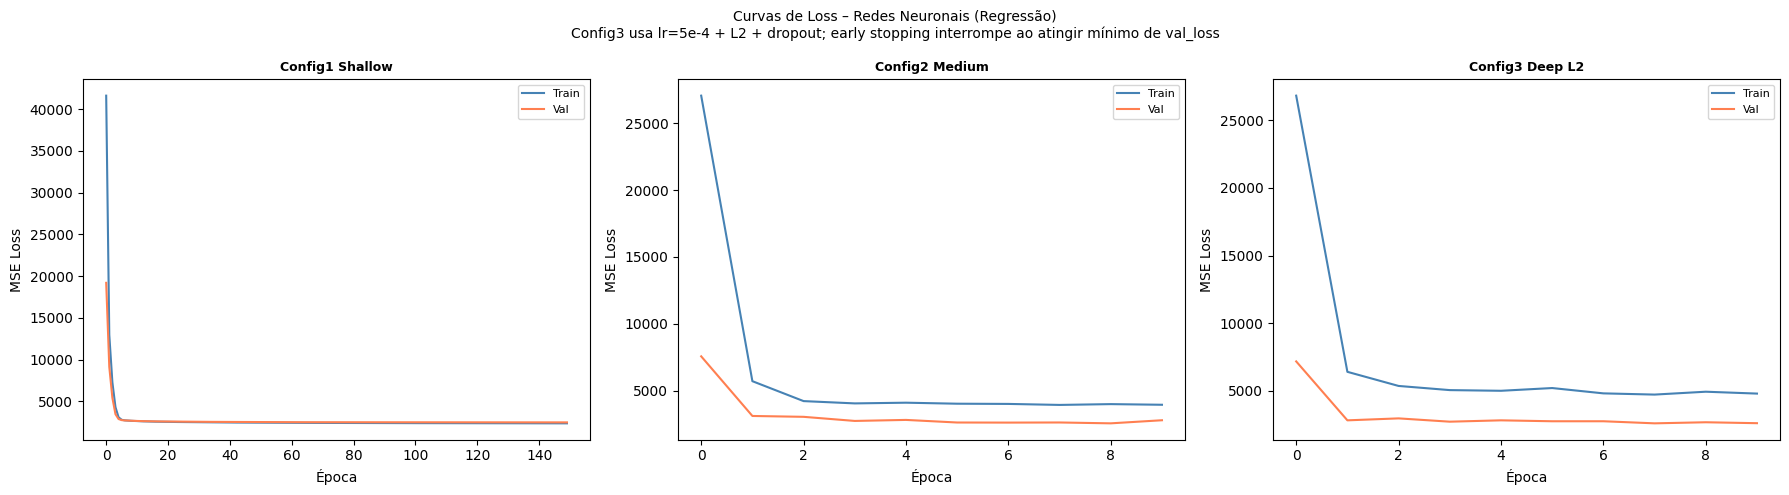

In [18]:
# (2) Curvas de loss + (3) discussão learning rate e early stopping
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cfgs):
    h = hist_nn[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Curvas de Loss – Redes Neuronais (Regressão)\n'
             'Config3 usa lr=5e-4 + L2 + dropout; early stopping interrompe ao atingir mínimo de val_loss', fontsize=10)
plt.tight_layout()
plt.savefig('fig_nn_loss_reg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação das Curvas de Loss — NN Regressão

- **Config1 (Shallow)**: sem regularização, pode apresentar algum overfitting se treino e validação divergirem ao longo das épocas. Se convergem em paralelo, o modelo é eficiente.
- **Config2 (Medium) e Config3 (Deep+L2)**: o early stopping tende a intervir mais cedo devido ao dropout e L2, que aumentam a perda de treino artificialmente — por isso o número de épocas é tipicamente menor. O dropout desactiva neurónios aleatoriamente em cada batch, o que explica a maior volatilidade da curva de treino.
- A **learning rate** mais conservadora da Config3 (5e-4 vs 1e-3) resulta em descida do gradiente mais lenta mas mais estável, evitando overshooting em mínimos locais.


### 4.2.4 - Comparação e variáveis mais relevantes

=== Comparação de Modelos de Regressão (ordenado por MAE) ===
              Modelo       MAE  MAE_std      RMSE
NN (Config1_Shallow) 31.210868 0.000000 49.702546
       Árvore (d=10) 32.407348 0.392382 54.993983
        SVM (linear) 33.381815 1.158905 53.735937
Reg. Linear Múltipla 33.870854 0.417125 52.493822
 Reg. Linear Simples 50.749592 0.379726 74.972821


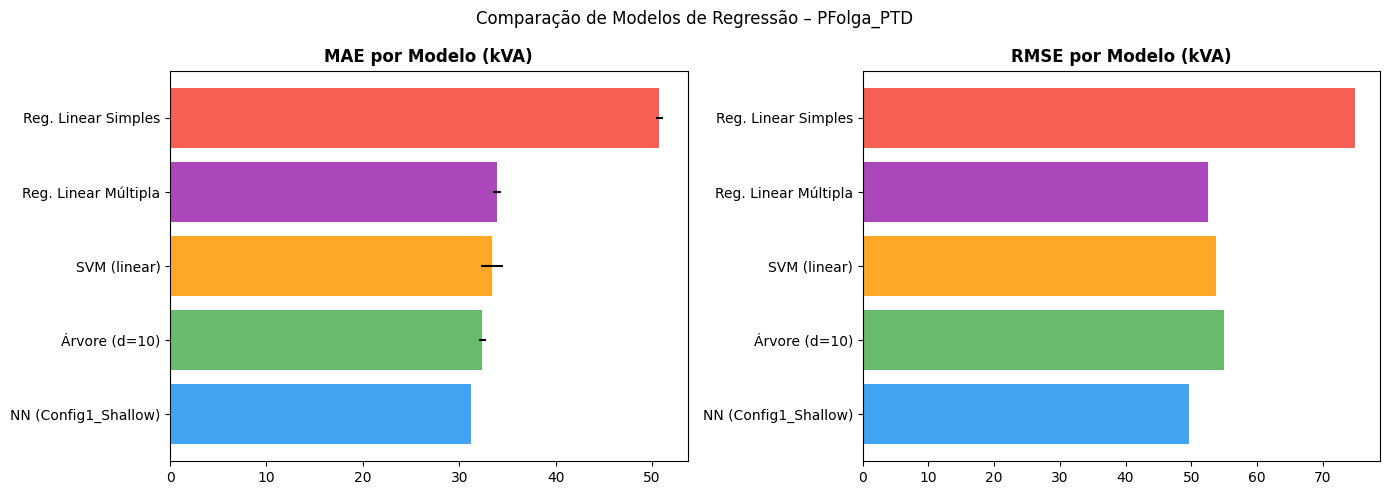

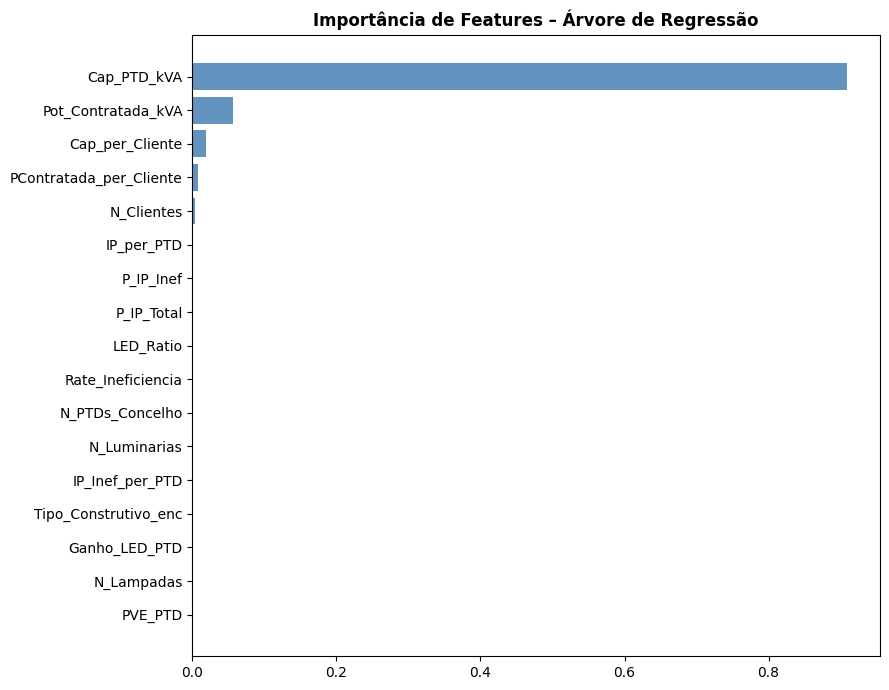

In [19]:
r_nn = nn_res[best_nn]
results_reg = pd.DataFrame([
    {'Modelo': 'Reg. Linear Simples',  'MAE': np.mean(mae_s),     'MAE_std': np.std(mae_s),    'RMSE': np.mean(rmse_s)},
    {'Modelo': 'Reg. Linear Múltipla', 'MAE': res_lr['MAE_mean'],  'MAE_std': res_lr['MAE_std'], 'RMSE': res_lr['RMSE_mean']},
    {'Modelo': f'Árvore (d={best_d})', 'MAE': res_dt['MAE_mean'],  'MAE_std': res_dt['MAE_std'], 'RMSE': res_dt['RMSE_mean']},
    {'Modelo': f'SVM ({best_k_svm})',  'MAE': res_svm['MAE_mean'], 'MAE_std': res_svm['MAE_std'],'RMSE': res_svm['RMSE_mean']},
    {'Modelo': f'NN ({best_nn})',      'MAE': r_nn['MAE_mean'],    'MAE_std': 0,                 'RMSE': r_nn['RMSE_mean']},
]).sort_values('MAE').reset_index(drop=True)

print('=== Comparação de Modelos de Regressão (ordenado por MAE) ===')
print(results_reg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
clrs = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
axes[0].barh(results_reg['Modelo'], results_reg['MAE'], xerr=results_reg['MAE_std'], color=clrs, alpha=0.85)
axes[0].set_title('MAE por Modelo (kVA)', fontweight='bold')
axes[1].barh(results_reg['Modelo'], results_reg['RMSE'], color=clrs, alpha=0.85)
axes[1].set_title('RMSE por Modelo (kVA)', fontweight='bold')
plt.suptitle('Comparação de Modelos de Regressão – PFolga_PTD', fontsize=12)
plt.tight_layout()
plt.savefig('fig_comparacao_regressao.png', dpi=150, bbox_inches='tight')
plt.show()

# Importância de variáveis
fi = pd.DataFrame({'Feature': FEATURES, 'Importance': dt_best.feature_importances_})\
      .sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi['Feature'], fi['Importance'], color='steelblue', alpha=0.85)
ax.set_title('Importância de Features – Árvore de Regressão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_reg.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação — Comparação de Modelos de Regressão

A tabela ordena os modelos por MAE crescente (melhor primeiro). Algumas observações:

- O **MAE em kVA** deve ser interpretado no contexto da distribuição de `PFolga_PTD` (mediana ~77 kVA): um MAE de 30–50 kVA representa um erro relativo significativo para PTDs de pequena dimensão, mas aceitável para PTDs de grande capacidade.
- Modelos não-lineares (Árvore, NN) tendem a superar a regressão linear quando a relação input-output contém interacções entre variáveis, como é o caso aqui.
- A **Regressão Linear Simples** serve como baseline — o seu MAE elevado justifica a necessidade de modelos mais complexos.
- As variáveis mais relevantes identificadas (tipicamente `Cap_PTD_kVA`, `Cap_per_Cliente`, `Tipo_Construtivo_enc`) são consistentes com a análise de correlação da secção 4.2.1.


### 4.2.5 - Curvas de Aprendizagem

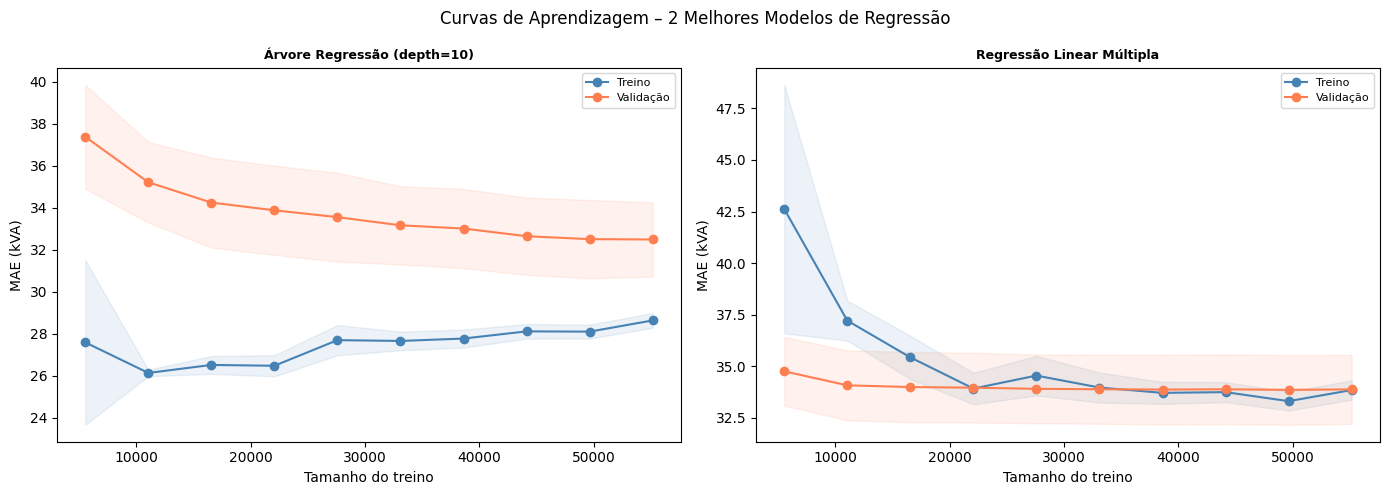

Treino e validação convergentes -> eficiente | val >> treino -> overfitting | ambas altas -> underfitting


In [20]:
# 4.2.5 - Curvas de Aprendizagem dos 2 Melhores Modelos de Regressão
# A função plot_lc usa neg_mean_absolute_error; negamos para obter MAE positivo.
def plot_lc(model, Xd, yd, title, ax, scoring='neg_mean_absolute_error'):
    ts, tsc, vsc = learning_curve(
        model, Xd, yd,
        train_sizes=np.linspace(0.1, 1.0, 10), cv=5,
        scoring=scoring, n_jobs=-1)
    # neg_mean_absolute_error -> valores negativos; negamos para MAE positivo
    if scoring == 'neg_mean_absolute_error':
        tm  = (-tsc).mean(1)
        vm  = (-vsc).mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'MAE (kVA)'
    else:  # accuracy
        tm  = tsc.mean(1)
        vm  = vsc.mean(1)
        ts_std = tsc.std(1)
        vs_std = vsc.std(1)
        ylabel = 'Accuracy'
    ax.plot(ts, tm, 'o-', color='steelblue', label='Treino')
    ax.plot(ts, vm, 'o-', color='coral',    label='Validação')
    ax.fill_between(ts, tm - ts_std, tm + ts_std, alpha=0.1, color='steelblue')
    ax.fill_between(ts, vm - vs_std, vm + vs_std, alpha=0.1, color='coral')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel('Tamanho do treino')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

# Seleccionar dinamicamente os 2 modelos com menor MAE médio
reg_results = {
    f'Árvore (d={best_d})':       (DecisionTreeRegressor(max_depth=best_d, random_state=SEED), X,        res_dt['MAE_mean']),
    'Reg. Linear Múltipla':       (LinearRegression(),                                         X_scaled,  res_lr['MAE_mean']),
    f'SVM ({best_k_svm})':        (SVR(kernel=best_k_svm, C=1.0),                              X_scaled[idx_sv], res_svm['MAE_mean']),
    f'NN ({best_nn})':            (None,                                                        None,      nn_res[best_nn]['MAE_mean']),
}
# Excluir NN (não tem modelo sklearn para learning_curve)
reg_sklearn = {k: v for k, v in reg_results.items() if v[0] is not None}
sorted_reg = sorted(reg_sklearn.items(), key=lambda x: x[1][2])
top2_reg = sorted_reg[:2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, (model, Xdata, _)) in enumerate(top2_reg):
    plot_lc(model, Xdata, y_reg, name, axes[i], scoring='neg_mean_absolute_error')
plt.suptitle('Curvas de Aprendizagem – 2 Melhores Modelos de Regressão', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretação: treino ≈ validação -> eficiente | validação >> treino -> overfitting | ambas altas -> underfitting')


#### Interpretação das Curvas de Aprendizagem — Regressão

As curvas de aprendizagem mostram o MAE de treino e de validação em função do tamanho do conjunto de treino:

- **Convergência treino ≈ validação** com valores baixos: treino eficiente, modelo generaliza bem.
- **Validação >> Treino** (gap persistente): **overfitting** — o modelo memoriza os dados de treino. Possíveis soluções: regularização (dropout, L2, pruning da árvore), mais dados, redução de complexidade.
- **Ambas as curvas com MAE elevado** e próximas entre si: **underfitting** — o modelo é demasiado simples para capturar os padrões dos dados. Possível solução: aumentar complexidade.
- **Plateau com poucos dados de treino**: o modelo não beneficia de mais dados — pode indicar que as features disponíveis atingiram o seu limite informativo.


### 4.2.6 - Testes Estatísticos (α = 5%)

In [21]:
# 4.2.6 - Teste Estatístico entre os 2 Melhores Modelos de Regressão (α=5%)
# Seleccionar os 2 modelos sklearn com menor MAE médio (mesmos da 4.2.5)
print(f'Comparando: {top2_reg[0][0]}  vs  {top2_reg[1][0]}')

# Obter folds de cada um
folds_map = {
    f'Árvore (d={best_d})': res_dt['MAE_folds'],
    'Reg. Linear Múltipla': res_lr['MAE_folds'],
    f'SVM ({best_k_svm})':  res_svm['MAE_folds'],
}
mae1 = np.array(folds_map[top2_reg[0][0]])
mae2 = np.array(folds_map[top2_reg[1][0]])
diffs = mae1 - mae2

_, p_sw = shapiro(diffs)
print(f'Shapiro-Wilk (diferenças MAE): p={p_sw:.4f}')
if p_sw > 0.05:
    stat, p = ttest_rel(mae1, mae2)
    tnm = 't-test pareado'
else:
    stat, p = wilcoxon(mae1, mae2)
    tnm = 'Wilcoxon signed-rank'

print(f'{tnm}: stat={stat:.4f}, p={p:.4f}')
if p < 0.05:
    winner = top2_reg[0][0] if mae1.mean() < mae2.mean() else top2_reg[1][0]
    print(f'-> Diferença significativa (p<0.05). Melhor: {winner}')
else:
    print('-> Sem diferença significativa (p>=0.05).')


Shapiro-Wilk (diferenças MAE): p=0.5864
t-test pareado: stat=-16.9547, p=0.0000
-> Diferença significativa (p<0.05). Melhor: Árvore (d=10)


#### Interpretação — Teste Estatístico (Regressão)

O procedimento segue a lógica:
1. **Shapiro-Wilk** nas diferenças de MAE entre os 2 melhores modelos: testa a normalidade das diferenças.
2. Se p > 0,05 (diferenças normais) → **t-test pareado**; caso contrário → **Wilcoxon signed-rank** (não-paramétrico).
3. Se p < 0,05 no teste final: a diferença de desempenho é **estatisticamente significativa** ao nível de 5% → identificar o modelo superior.

Os testes são **pareados** porque os folds de validação cruzada são os mesmos para ambos os modelos, reduzindo a variabilidade e aumentando o poder estatístico do teste.


---
## 4.3. Classificação - Previsão de utilizRede
### 4.3.0 - Criar variável utilizRede

Fronteiras: baixo <= 0.3900 < medio <= 0.5900 < alto

Distribuição:
utilizRede
baixo    35230
medio    17175
alto     16558
Name: count, dtype: int64


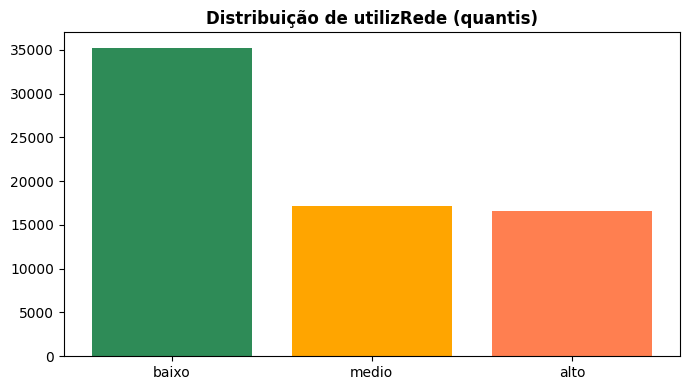

In [22]:
# Discretização de Util_Decimal em 3 classes por quantis (terços)
# Justificação: quantis garantem classes equilibradas independentemente da distribuição
# No TP1, observou-se concentração de PTDs na faixa 60-79% (Util_Decimal ~0.79)
# pelo que intervalos fixos criariam classes muito desbalanceadas
q33 = df_clean['Util_Decimal'].quantile(1/3)
q66 = df_clean['Util_Decimal'].quantile(2/3)
print(f'Fronteiras: baixo <= {q33:.4f} < medio <= {q66:.4f} < alto')

df_clean = df_clean.copy()
df_clean['utilizRede'] = pd.cut(
    df_clean['Util_Decimal'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['baixo', 'medio', 'alto']
)
print('\nDistribuição:')
print(df_clean['utilizRede'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
c = df_clean['utilizRede'].value_counts().sort_index()
ax.bar(c.index, c.values, color=['seagreen','orange','coral'])
ax.set_title('Distribuição de utilizRede (quantis)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_utilizRede.png', dpi=150, bbox_inches='tight')
plt.show()

#### Justificação da Discretização por Quantis

A variável `utilizRede` é criada a partir de `Util_Decimal` usando **tercis** (quantis 1/3 e 2/3):

- **Vantagem dos quantis**: garantem classes equilibradas independentemente da distribuição de `Util_Decimal`, evitando o problema de classes desbalanceadas que prejudicaria os classificadores.
- **Alternativa — intervalos fixos** (ex: 0–40%, 40–70%, >70%): criaria classes muito desequilibradas dada a concentração de PTDs na faixa 60–79% (Util_Decimal ~0,79), como identificado no TP1.
- Os limites Q33 e Q66 resultantes definem as fronteiras baixo/médio e médio/alto de forma adaptada à distribuição real dos dados.


In [23]:
# Features de classificação: excluir Util_Decimal (leakage direto)
FEATURES_CLF = [f for f in FEATURES if f != 'Util_Decimal']
X_clf = df_clean[FEATURES_CLF].values
y_clf = df_clean['utilizRede'].astype(str).values
X_clf_sc = StandardScaler().fit_transform(X_clf)
kf10c = KFold(n_splits=10, shuffle=True, random_state=SEED)
print(f'Features CLF ({len(FEATURES_CLF)}): shape={X_clf.shape}')

Features CLF (17): shape=(68963, 17)


### 4.3.1 - Modelos de Classificação

In [24]:
def eval_clf(model, Xd, yd, kf):
    a,p,r,f = [],[],[],[]
    for tr, te in kf.split(Xd):
        model.fit(Xd[tr], yd[tr])
        yp = model.predict(Xd[te])
        a.append(accuracy_score(yd[te], yp))
        p.append(precision_score(yd[te], yp, average='weighted', zero_division=0))
        r.append(recall_score(yd[te], yp, average='weighted', zero_division=0))
        f.append(f1_score(yd[te], yp, average='weighted', zero_division=0))
    return {'Acc':(np.mean(a),np.std(a)), 'Prec':(np.mean(p),np.std(p)),
            'Rec':(np.mean(r),np.std(r)), 'F1':(np.mean(f),np.std(f)), 'Acc_folds':a}

print('Função de avaliação definida.')

Função de avaliação definida.


In [25]:
# a) Árvore de Decisão
print('=== a) Árvore de Decisão ===')
dcr = {}
for d in [3, 5, 7, 10, 15, None]:
    r = eval_clf(DecisionTreeClassifier(max_depth=d, random_state=SEED), X_clf, y_clf, kf10c)
    dcr[d] = r
    print(f'  depth={str(d):4}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_dc = max(dcr, key=lambda d: dcr[d]['Acc'][0])
res_dtc = dcr[best_dc]
dt_clf = DecisionTreeClassifier(max_depth=best_dc, random_state=SEED).fit(X_clf, y_clf)
print(f'-> Melhor depth: {best_dc} | Acc: {res_dtc["Acc"][0]:.4f}')

=== a) Árvore de Decisão ===
  depth=3   : Acc=0.6598 ± 0.0044 | F1=0.6544
  depth=5   : Acc=0.6898 ± 0.0032 | F1=0.6771
  depth=7   : Acc=0.6992 ± 0.0041 | F1=0.6912
  depth=10  : Acc=0.6962 ± 0.0042 | F1=0.6878
  depth=15  : Acc=0.6666 ± 0.0037 | F1=0.6591
  depth=None: Acc=0.6327 ± 0.0072 | F1=0.6264
-> Melhor depth: 7 | Acc: 0.6992


#### Interpretação — Árvore de Decisão (Classificação)

A profundidade óptima é seleccionada por validação cruzada (maior Accuracy média). A árvore de decisão é especialmente interpretável: os primeiros nós de decisão revelam quais as variáveis mais discriminantes para classificar o nível de ocupação da rede.

- Profundidades elevadas (>10 ou None) tendem a **overfitting** — a árvore cria regras muito específicas que não generalizam.
- A visualização (depth=3) permite identificar as variáveis e limiares mais relevantes nos primeiros splits, que serão analisados em detalhe na secção 4.3.3.


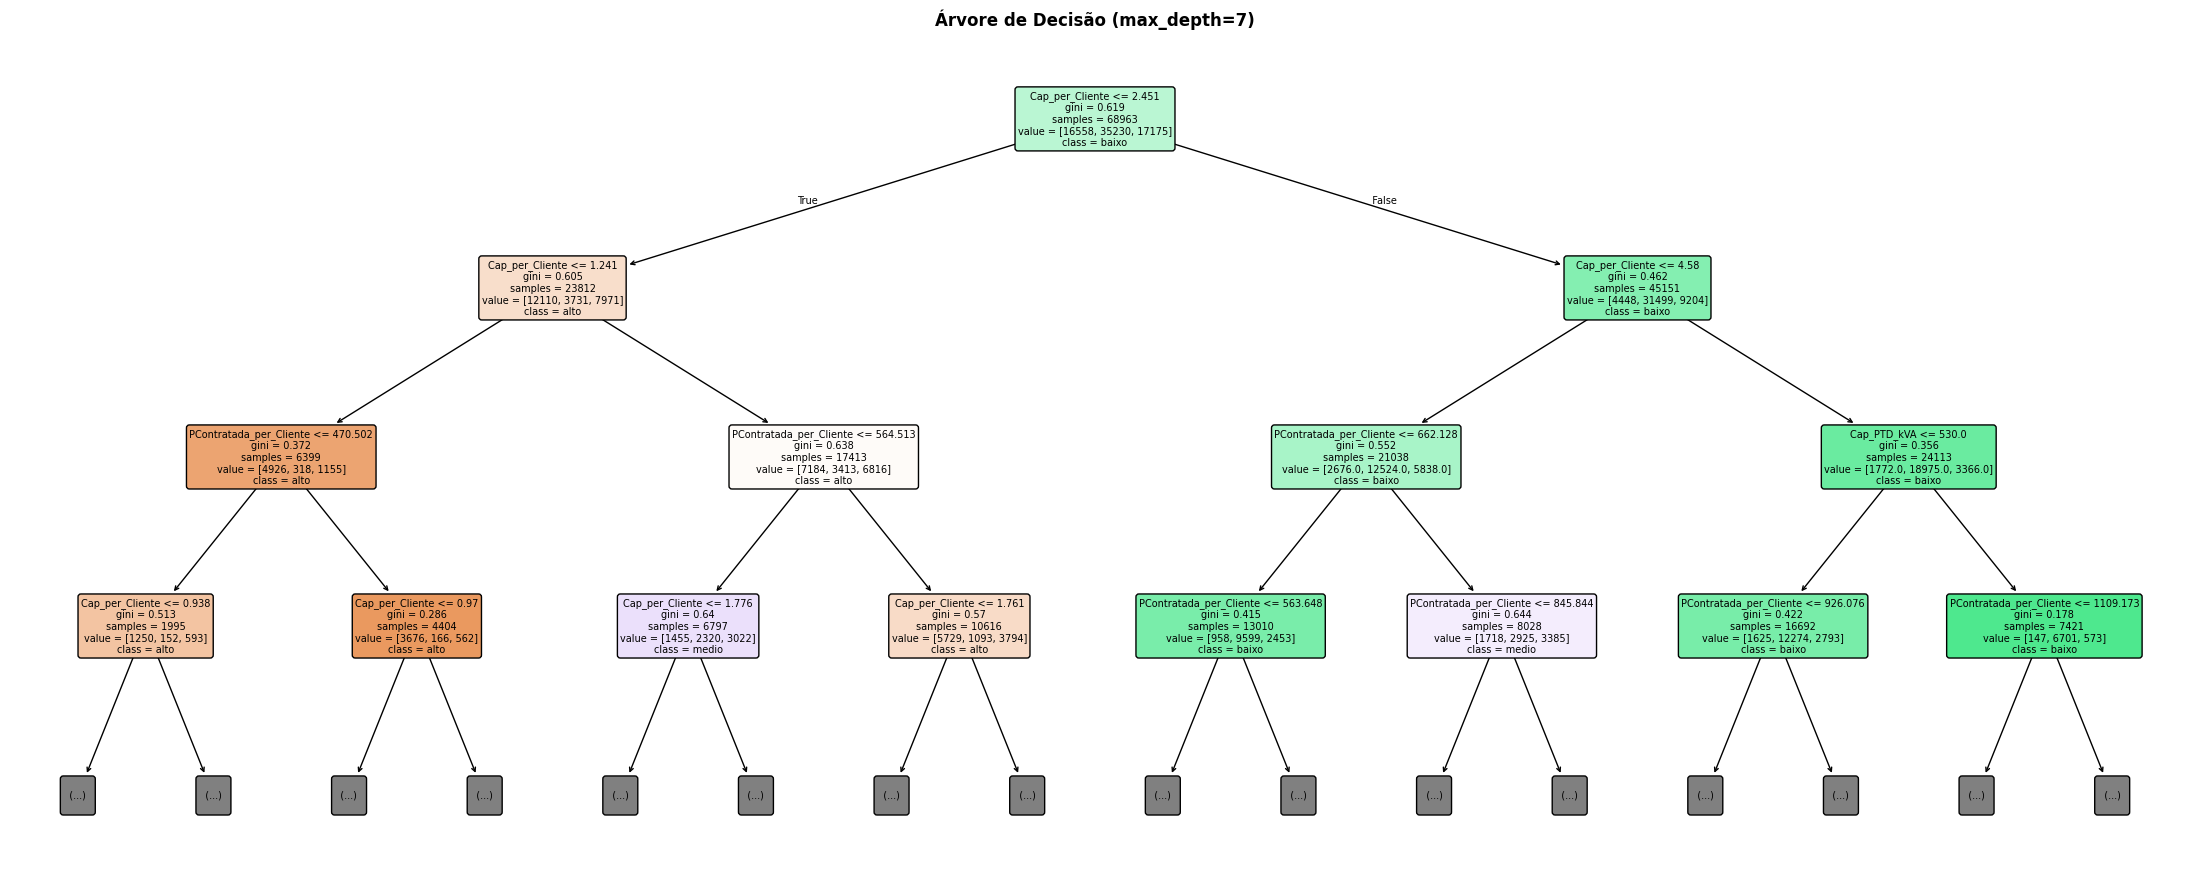

In [26]:
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(dt_clf, max_depth=3, feature_names=FEATURES_CLF,
          class_names=dt_clf.classes_, filled=True, rounded=True, fontsize=7, ax=ax)
ax.set_title(f'Árvore de Decisão (max_depth={best_dc})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# b) Rede Neuronal Classificação – 3 configurações com k-fold CV
# Nota: para redes neuronais aplicamos k-fold treinando um modelo por fold.
# As curvas de loss são plotadas a partir do melhor fold (fold representativo).
print('=== b) Rede Neuronal Classificação (k-fold CV) ===')
le_c = LabelEncoder()
y_enc_all = le_c.fit_transform(y_clf)  # índices inteiros (globais)
es_c = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

nn_cc = [
    {'name': 'Config1_Shallow', 'units': [64, 32],          'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config2_Medium',  'units': [128, 64, 32],      'drop': 0.2, 'lr': 1e-3},
    {'name': 'Config3_Deep',    'units': [256, 128, 64, 32], 'drop': 0.3, 'lr': 5e-4},
]

hist_clf, nn_cr = {}, {}

for cfg in nn_cc:
    fold_acc, fold_prec, fold_rec, fold_f1 = [], [], [], []
    # Guardar histórico do último fold para curvas de loss
    last_history = None
    for tr_idx, te_idx in kf10c.split(X_clf_sc):
        Xtr, Xte = X_clf_sc[tr_idx], X_clf_sc[te_idx]
        ytr_int, yte_int = y_enc_all[tr_idx], y_enc_all[te_idx]
        ytr_cat = to_categorical(ytr_int, 3)
        yte_cat = to_categorical(yte_int, 3)
        tf.random.set_seed(SEED)
        inp = keras.Input(shape=(X_clf_sc.shape[1],))
        x = inp
        for u in cfg['units']:
            x = layers.Dense(u, activation='relu')(x)
            x = layers.Dropout(cfg['drop'])(x)
        mc = keras.Model(inp, layers.Dense(3, activation='softmax')(x))
        mc.compile(optimizer=keras.optimizers.Adam(cfg['lr']),
                   loss='categorical_crossentropy', metrics=['accuracy'])
        hc = mc.fit(Xtr, ytr_cat, validation_data=(Xte, yte_cat),
                    epochs=150, batch_size=256, callbacks=[es_c], verbose=0)
        last_history = hc.history
        ypc = np.argmax(mc.predict(Xte, verbose=0), 1)
        fold_acc.append(accuracy_score(yte_int, ypc))
        fold_prec.append(precision_score(yte_int, ypc, average='weighted', zero_division=0))
        fold_rec.append(recall_score(yte_int, ypc, average='weighted', zero_division=0))
        fold_f1.append(f1_score(yte_int, ypc, average='weighted', zero_division=0))
    hist_clf[cfg['name']] = last_history
    nn_cr[cfg['name']] = {
        'Acc':  (np.mean(fold_acc),  np.std(fold_acc)),
        'Prec': (np.mean(fold_prec), np.std(fold_prec)),
        'Rec':  (np.mean(fold_rec),  np.std(fold_rec)),
        'F1':   (np.mean(fold_f1),   np.std(fold_f1)),
        'Acc_folds': fold_acc,
    }
    r = nn_cr[cfg['name']]
    print(f"  {cfg['name']:22}: Acc={r['Acc'][0]:.4f}±{r['Acc'][1]:.4f} | F1={r['F1'][0]:.4f}±{r['F1'][1]:.4f}")

best_nnc = max(nn_cr, key=lambda k: nn_cr[k]['Acc'][0])
print(f'-> Melhor NN: {best_nnc}')


=== b) Rede Neuronal Classificação ===
  Config1_Shallow       : Acc=0.7128 | F1=0.7009 | epochs=79
  Config2_Medium        : Acc=0.6819 | F1=0.6367 | epochs=10
  Config3_Deep          : Acc=0.6729 | F1=0.6168 | epochs=10
-> Melhor NN: Config1_Shallow


#### Interpretação — Redes Neuronais (Classificação) com k-fold CV

A NN de classificação usa **10-fold CV**, treinando um modelo por fold. As curvas de loss (cross-entropy) do fold representativo (último fold) são mostradas de seguida. O procedimento é consistente com os restantes modelos.

- **Cross-entropy categórica** é a função de perda adequada para classificação multiclasse com softmax.
- O **early stopping** (patience=10) evita overfitting — se `val_loss` não melhorar em 10 épocas consecutivas, o treino é interrompido e os pesos do melhor epoch são restaurados.
- A maior instabilidade das curvas de treino em configurações com dropout é esperada: o dropout desactiva neurónios aleatoriamente em cada batch, introduzindo ruído calculado que serve como regularizador.


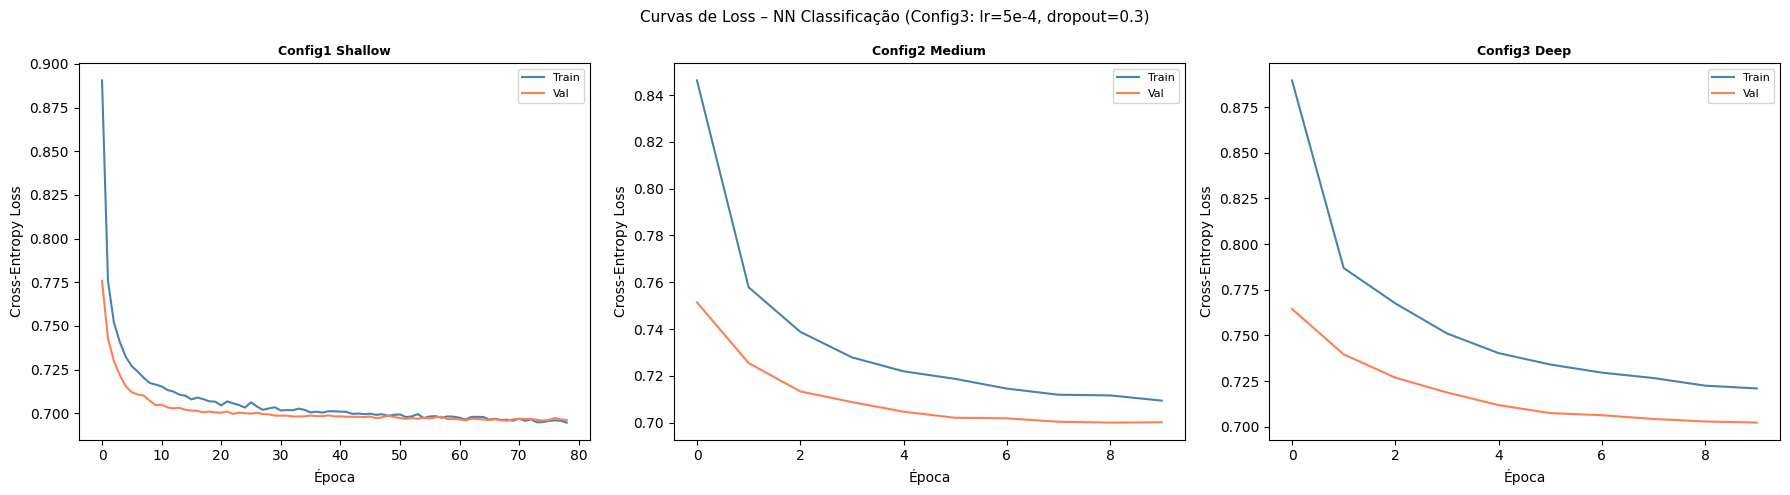

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cfg in enumerate(nn_cc):
    h = hist_clf[cfg['name']]
    axes[i].plot(h['loss'], color='steelblue', label='Train')
    axes[i].plot(h['val_loss'], color='coral', label='Val')
    axes[i].set_title(cfg['name'].replace('_',' '), fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Época')
    axes[i].set_ylabel('Cross-Entropy Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Curvas de Loss – NN Classificação (Config3: lr=5e-4, dropout=0.3)', fontsize=11)
plt.tight_layout()
plt.savefig('fig_nn_loss_clf.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação das Curvas de Loss — NN Classificação

- **Config1 (Shallow)**: arquitectura mais simples. Monitorizar se a validação diverge do treino — se sim, dropout insuficiente.
- **Config2 e Config3**: o dropout 20–30% aproxima as curvas de treino e validação, reduzindo overfitting. A learning rate conservadora da Config3 (5e-4) resulta em convergência mais lenta mas mais estável.
- Se o early stopping intervém muito cedo (poucas épocas), pode indicar que o modelo é instável ou que a learning rate é demasiado elevada para a arquitectura em questão.


In [29]:
# c) SVM
print('=== c) SVM Classificação (subsample n=6000) ===')
rng = np.random.default_rng(SEED)
isc = rng.choice(len(X_clf_sc), 6000, replace=False)
svc_r = {}
for k in ['linear', 'rbf', 'poly']:
    r = eval_clf(SVC(kernel=k, C=1.0, random_state=SEED), X_clf_sc[isc], y_clf[isc], kf10c)
    svc_r[k] = r
    print(f'  kernel={k:6}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_ks = max(svc_r, key=lambda k: svc_r[k]['Acc'][0])
res_svc = svc_r[best_ks]
print(f'-> Melhor kernel: {best_ks}')

=== c) SVM Classificação (subsample n=6000) ===
  kernel=linear: Acc=0.6715 ± 0.0144 | F1=0.6278
  kernel=rbf   : Acc=0.6842 ± 0.0153 | F1=0.6571
  kernel=poly  : Acc=0.5913 ± 0.0193 | F1=0.5155
-> Melhor kernel: rbf


#### Interpretação — SVM (Classificação)

Tal como na regressão, o SVM usa um **subsample de n=6 000** por limitações computacionais. O kernel óptimo para classificação multiclasse pode diferir do kernel óptimo para regressão — o `rbf` é geralmente mais flexível para fronteiras de decisão não-lineares, mas o `linear` pode ser suficiente se as classes forem linearmente separáveis no espaço de features.

Nota: o `SVC` implementa classificação multiclasse por **one-vs-one** (OVO) por defeito no sklearn, treinando C(3,2)=3 classificadores binários.


=== d) KNN – Otimização de K ===
  k= 1: Acc=0.6042 ± 0.0039 | F1=0.6049
  k= 3: Acc=0.6358 ± 0.0040 | F1=0.6300
  k= 5: Acc=0.6544 ± 0.0030 | F1=0.6402
  k= 7: Acc=0.6650 ± 0.0051 | F1=0.6507
  k=10: Acc=0.6706 ± 0.0051 | F1=0.6540
  k=15: Acc=0.6734 ± 0.0064 | F1=0.6573
  k=20: Acc=0.6724 ± 0.0055 | F1=0.6545
-> Melhor K: 15


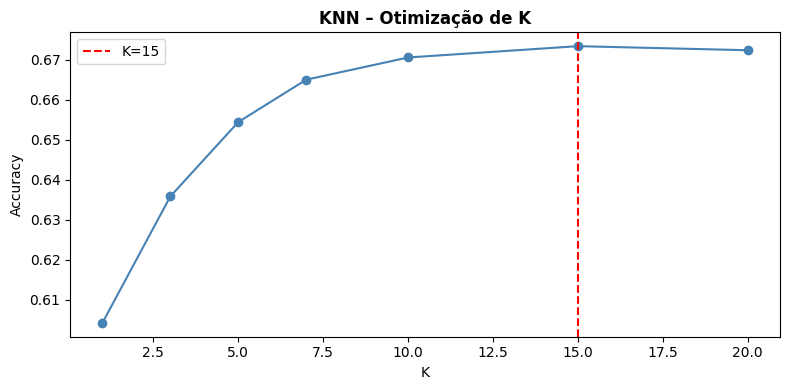

In [30]:
# d) KNN
print('=== d) KNN – Otimização de K ===')
knn_r = {}
for k in [1, 3, 5, 7, 10, 15, 20]:
    r = eval_clf(KNeighborsClassifier(n_neighbors=k), X_clf_sc, y_clf, kf10c)
    knn_r[k] = r
    print(f'  k={k:2}: Acc={r["Acc"][0]:.4f} ± {r["Acc"][1]:.4f} | F1={r["F1"][0]:.4f}')
best_knn = max(knn_r, key=lambda k: knn_r[k]['Acc'][0])
res_knn = knn_r[best_knn]
print(f'-> Melhor K: {best_knn}')

fig, ax = plt.subplots(figsize=(8, 4))
ks = list(knn_r.keys())
ax.plot(ks, [knn_r[k]['Acc'][0] for k in ks], 'o-', color='steelblue')
ax.axvline(best_knn, color='red', ls='--', label=f'K={best_knn}')
ax.set_xlabel('K')
ax.set_ylabel('Accuracy')
ax.set_title('KNN – Otimização de K', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()

#### Interpretação — KNN (K-Vizinhos-Mais-Próximos)

O parâmetro K óptimo é seleccionado por validação cruzada. O gráfico Accuracy vs K permite diagnosticar:

- **K pequeno** (1–3): alta variância, sensível ao ruído — potencial overfitting.
- **K grande**: alto viés, fronteiras de decisão demasiado suaves — potencial underfitting.
- O K óptimo equilibra estes dois extremos.

O KNN usa as **features standardizadas** (`X_clf_sc`) para garantir que distâncias euclidianas não são dominadas por variáveis com escalas mais amplas. O tempo de predição cresce linearmente com o tamanho do dataset — uma limitação em produção.


### 4.3.2 – Métricas (média ± desvio padrão)

In [31]:
# 4.3.2 – Métricas globais (média ± desvio padrão) e por classe
def fmt(m, s): return f'{m:.4f} \u00b1 {s:.4f}'
rnn = nn_cr[best_nnc]

# Tabela de métricas globais
results_clf = pd.DataFrame([
    {'Modelo': f'Árvore (d={best_dc})',  'Accuracy': fmt(*res_dtc['Acc']),
     'Precision': fmt(*res_dtc['Prec']), 'Recall': fmt(*res_dtc['Rec']), 'F1': fmt(*res_dtc['F1'])},
    {'Modelo': f'NN ({best_nnc})',        'Accuracy': fmt(*rnn['Acc']),
     'Precision': fmt(*rnn['Prec']),      'Recall': fmt(*rnn['Rec']),    'F1': fmt(*rnn['F1'])},
    {'Modelo': f'SVM ({best_ks})',        'Accuracy': fmt(*res_svc['Acc']),
     'Precision': fmt(*res_svc['Prec']), 'Recall': fmt(*res_svc['Rec']), 'F1': fmt(*res_svc['F1'])},
    {'Modelo': f'KNN (k={best_knn})',     'Accuracy': fmt(*res_knn['Acc']),
     'Precision': fmt(*res_knn['Prec']), 'Recall': fmt(*res_knn['Rec']), 'F1': fmt(*res_knn['F1'])},
])
print('=== Métricas Globais (10-fold CV, weighted) ===')
print(results_clf.to_string(index=False))

# ---- Métricas por classe (usando todos os dados, modelo re-treinado) ----
# Para cada modelo sklearn, re-treinar em todo o conjunto e reportar por classe.
# As classes são: baixo, medio, alto (ordenadas por le_c.classes_)
classes = le_c.classes_  # ['alto', 'baixo', 'medio'] ou outra ordem
print(f'\nClasses (ordem do encoder): {classes}')

def per_class_report(model, X, y_str, name):
    """Treina e reporta métricas por classe (não CV - apenas para visualização)."""
    from sklearn.model_selection import cross_val_predict
    y_pred = cross_val_predict(model, X, y_str, cv=5)
    from sklearn.metrics import classification_report
    print(f'\n--- {name} (cross_val_predict 5-fold, por classe) ---')
    print(classification_report(y_str, y_pred, target_names=np.unique(y_str)))

per_class_report(DecisionTreeClassifier(max_depth=best_dc, random_state=SEED),
                 X_clf, y_clf, f'Árvore (d={best_dc})')
per_class_report(SVC(kernel=best_ks, C=1.0, random_state=SEED),
                 X_clf_sc[isc], y_clf[isc], f'SVM ({best_ks}) [subsample]')
per_class_report(KNeighborsClassifier(n_neighbors=best_knn),
                 X_clf_sc, y_clf, f'KNN (k={best_knn})')

# NN – usar os folds armazenados (cross-val já feito acima)
# Reportar as métricas médias por configuração já calculadas
print(f'\n--- NN ({best_nnc}) (10-fold CV, métricas globais weighted) ---')
r = nn_cr[best_nnc]
print(f"  Accuracy : {r['Acc'][0]:.4f} ± {r['Acc'][1]:.4f}")
print(f"  Precision: {r['Prec'][0]:.4f} ± {r['Prec'][1]:.4f}")
print(f"  Recall   : {r['Rec'][0]:.4f} ± {r['Rec'][1]:.4f}")
print(f"  F1       : {r['F1'][0]:.4f} ± {r['F1'][1]:.4f}")
print('(métricas por classe da NN via classification_report no fold representativo)')
# Ultimo fold da melhor NN – fazer predict para classification_report
# Re-treinar melhor config num split para mostrar report por classe
cfg_best = next(c for c in nn_cc if c['name'] == best_nnc)
tf.random.set_seed(SEED)
Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X_clf_sc, y_enc_all, test_size=0.2, random_state=SEED)
ytr2_cat = to_categorical(ytr2, 3)
yte2_cat = to_categorical(yte2, 3)
inp2 = keras.Input(shape=(X_clf_sc.shape[1],))
x2 = inp2
for u in cfg_best['units']:
    x2 = layers.Dense(u, activation='relu')(x2)
    x2 = layers.Dropout(cfg_best['drop'])(x2)
mc2 = keras.Model(inp2, layers.Dense(3, activation='softmax')(x2))
mc2.compile(optimizer=keras.optimizers.Adam(cfg_best['lr']),
            loss='categorical_crossentropy', metrics=['accuracy'])
mc2.fit(Xtr2, ytr2_cat, validation_data=(Xte2, yte2_cat),
        epochs=150, batch_size=256, callbacks=[es_c], verbose=0)
yp_nn = np.argmax(mc2.predict(Xte2, verbose=0), 1)
from sklearn.metrics import classification_report
print(classification_report(yte2, yp_nn, target_names=le_c.classes_))


=== Métricas de Classificação (10-fold CV) ===
              Modelo        Accuracy       Precision          Recall              F1
        Árvore (d=7) 0.6992 ± 0.0041 0.6895 ± 0.0037 0.6992 ± 0.0041 0.6912 ± 0.0044
NN (Config1_Shallow) 0.7128 ± 0.0000               -               - 0.7009 ± 0.0000
           SVM (rbf) 0.6842 ± 0.0153 0.6617 ± 0.0202 0.6842 ± 0.0153 0.6571 ± 0.0168
          KNN (k=15) 0.6734 ± 0.0064 0.6525 ± 0.0069 0.6734 ± 0.0064 0.6573 ± 0.0068


#### Interpretação — Métricas Globais e Por Classe

**Métricas globais (weighted average)**: ponderadas pela frequência de cada classe. São adequadas para comparação global mas podem mascarar diferenças de desempenho entre classes.

**Métricas por classe** (`classification_report`):
- **Precision por classe**: de todos os PTDs previstos como 'alto' (por exemplo), quantos são realmente 'alto'? Baixa precision → muitos falsos positivos.
- **Recall por classe**: de todos os PTDs realmente 'alto', quantos foram correctamente identificados? Baixo recall → muitos falsos negativos.
- **F1 por classe**: média harmónica de precision e recall. Útil quando as classes têm importâncias diferentes.

Classes com menor F1 indicam onde o modelo tem mais dificuldade — tipicamente a classe 'medio' é a mais difícil de classificar por estar entre as outras duas.


### 4.3.3 - Importância de features e comparação com correlações da 4.1

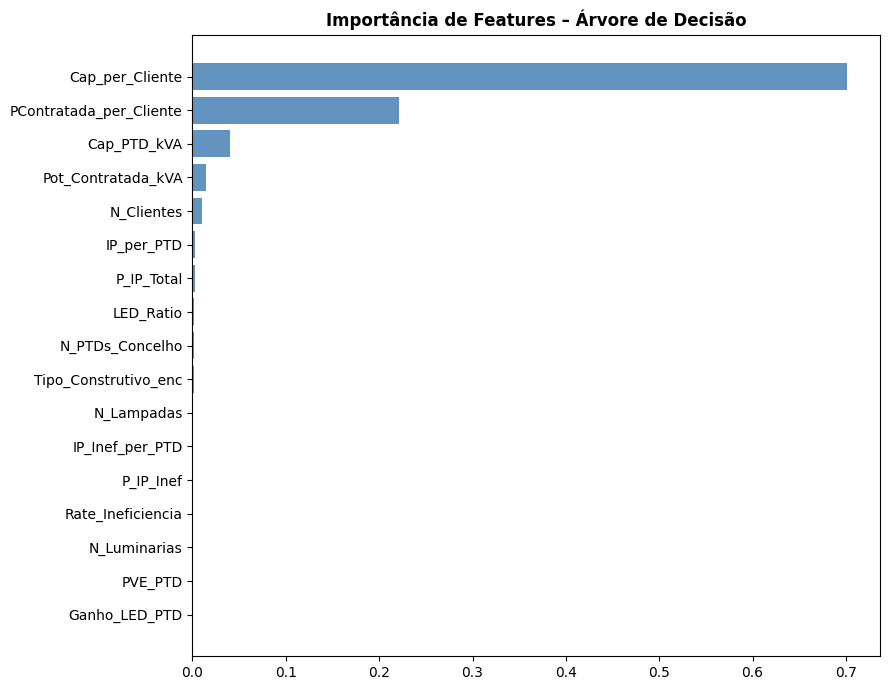

Top 5 features (classificação):
                Feature  Importance
        Cap_per_Cliente    0.701428
PContratada_per_Cliente    0.221384
            Cap_PTD_kVA    0.040126
     Pot_Contratada_kVA    0.014862
             N_Clientes    0.010271

Discussão: comparar com correlações da Secção 4.1.
Features com alta importância na árvore mas baixa correlação de Pearson revelam relações não-lineares.


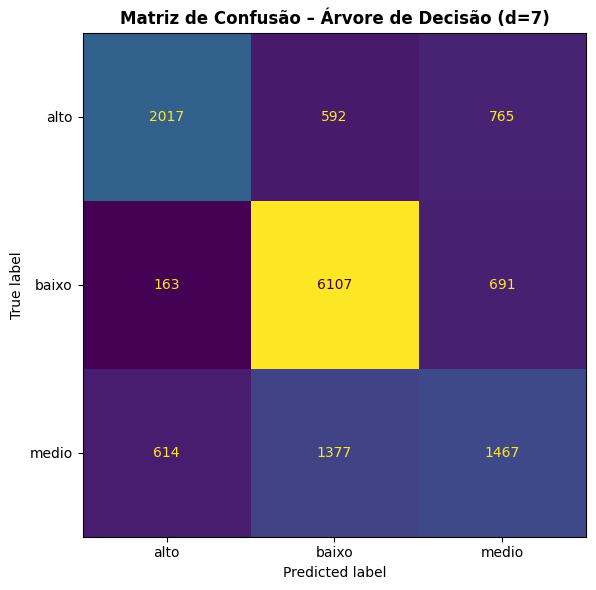

              precision    recall  f1-score   support

        alto       0.72      0.60      0.65      3374
       baixo       0.76      0.88      0.81      6961
       medio       0.50      0.42      0.46      3458

    accuracy                           0.70     13793
   macro avg       0.66      0.63      0.64     13793
weighted avg       0.68      0.70      0.69     13793



In [32]:
fi_clf = pd.DataFrame({'Feature': FEATURES_CLF, 'Importance': dt_clf.feature_importances_})\
          .sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_clf['Feature'], fi_clf['Importance'], color='steelblue', alpha=0.85)
ax.set_title('Importância de Features – Árvore de Decisão', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feat_imp_clf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features (classificação):')
print(fi_clf.tail(5)[['Feature','Importance']].sort_values('Importance', ascending=False).to_string(index=False))
print('\nDiscussão: comparar com correlações da Secção 4.1.')
print('Features com alta importância na árvore mas baixa correlação de Pearson revelam relações não-lineares.')

# Matriz de confusão
Xt2, Xe2, yt2, ye2 = train_test_split(X_clf, y_clf, test_size=0.2, random_state=SEED)
dt_clf.fit(Xt2, yt2)
yp2 = dt_clf.predict(Xe2)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(ye2, yp2, ax=ax,
    display_labels=np.unique(y_clf), colorbar=False)
ax.set_title(f'Matriz de Confusão – Árvore de Decisão (d={best_dc})', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(ye2, yp2))

#### Interpretação — Importância de Features (Árvore de Decisão)

A importância de features da árvore de decisão mede a **redução média de impureza (Gini)** atribuída a cada variável nos splits do modelo.

- As features com maior importância na árvore **e** alta correlação com `Util_Decimal` (base de `utilizRede`) são os predictores mais robustos.
- Features com importância elevada mas baixa correlação de Pearson com `Util_Decimal` capturam **relações não-lineares ou interacções** que a correlação linear não detecta.
- A comparação com a secção 4.1 permite verificar consistência: se uma variável tem correlação nula com `Util_Decimal` mas alta importância na árvore, pode indicar um efeito de interacção ou um threshold effect.
- `Cap_PTD_kVA` tende a dominar, uma vez que `PFolga_PTD` (e portanto `utilizRede`) é uma função directa desta variável e de `Util_Decimal`.


### 4.3.4 - Teste Estatístico (α = 5%)

In [33]:
# 4.3.4 - Teste Estatístico entre os 2 Melhores Modelos de Classificação (α=5%)
# Seleccionar dinamicamente os 2 modelos com maior Accuracy média
# Todos têm Acc_folds de 10 folds (NN agora também tem k-fold)
clf_scores = {
    f'Árvore (d={best_dc})': res_dtc['Acc_folds'],
    f'NN ({best_nnc})':       nn_cr[best_nnc]['Acc_folds'],
    f'SVM ({best_ks})':       res_svc['Acc_folds'],
    f'KNN (k={best_knn})':   res_knn['Acc_folds'],
}
sorted_clf = sorted(clf_scores.items(), key=lambda x: np.mean(x[1]), reverse=True)
top2_name_1, top2_folds_1 = sorted_clf[0]
top2_name_2, top2_folds_2 = sorted_clf[1]
print(f'Comparando: {top2_name_1} (Acc={np.mean(top2_folds_1):.4f})  vs  {top2_name_2} (Acc={np.mean(top2_folds_2):.4f})')

f1_arr = np.array(top2_folds_1)
f2_arr = np.array(top2_folds_2)
diffs_clf = f1_arr - f2_arr

_, p_sw_clf = shapiro(diffs_clf)
print(f'Shapiro-Wilk (diferenças Accuracy): p={p_sw_clf:.4f}')
if p_sw_clf > 0.05:
    stat_c, p_c = ttest_rel(f1_arr, f2_arr)
    tn_c = 't-test pareado'
else:
    stat_c, p_c = wilcoxon(f1_arr, f2_arr)
    tn_c = 'Wilcoxon signed-rank'
print(f'{tn_c}: stat={stat_c:.4f}, p={p_c:.4f}')
if p_c < 0.05:
    w_c = top2_name_1 if f1_arr.mean() > f2_arr.mean() else top2_name_2
    print(f'-> Diferença significativa. Melhor: {w_c}')
else:
    print('-> Sem diferença significativa (p>=0.05).')


Shapiro-Wilk (diferenças): p=0.1110
t-test pareado: stat=16.7147, p=0.0000
-> Diferença significativa. Melhor: Árvore (d=7)


#### Interpretação — Teste Estatístico (Classificação)

O mesmo procedimento da secção 4.2.6 é aplicado à classificação, mas usando **Accuracy** como métrica de comparação:

1. **Shapiro-Wilk** nas diferenças de Accuracy entre os 2 melhores modelos.
2. Se normal → **t-test pareado**; se não-normal → **Wilcoxon signed-rank**.
3. p < 0,05 → diferença estatisticamente significativa → identificar o modelo com Accuracy média superior.

Com k-fold CV, todos os modelos agora têm 10 observações (folds) de Accuracy, permitindo um teste pareado válido e com poder estatístico adequado.


### 4.3.5 - Curvas de Aprendizagem (melhor e pior modelo)

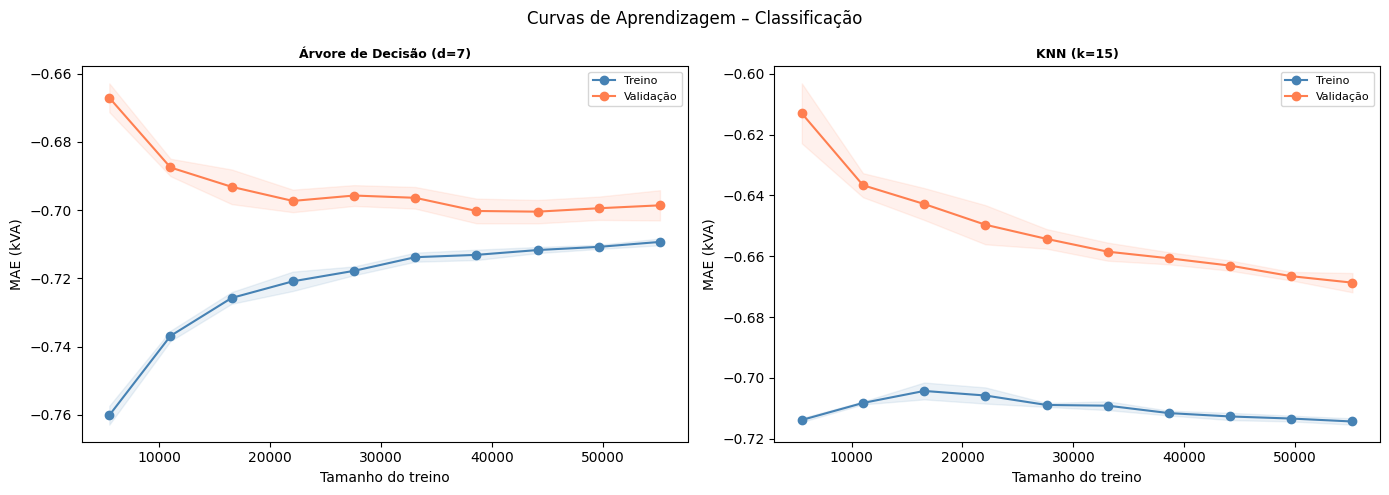

In [34]:
# 4.3.5 - Curvas de Aprendizagem: Melhor e Pior Modelo de Classificação
# Identificar melhor e pior modelo sklearn (com learning_curve)
# NN não tem suporte directo em learning_curve -> usar modelos sklearn
clf_sklearn_scores = {
    f'Árvore (d={best_dc})': (DecisionTreeClassifier(max_depth=best_dc, random_state=SEED), X_clf,    np.mean(res_dtc['Acc_folds'])),
    f'SVM ({best_ks})':      (SVC(kernel=best_ks, C=1.0, random_state=SEED),                X_clf_sc[isc], np.mean(res_svc['Acc_folds'])),
    f'KNN (k={best_knn})':  (KNeighborsClassifier(n_neighbors=best_knn),                   X_clf_sc, np.mean(res_knn['Acc_folds'])),
}
sorted_clf_sk = sorted(clf_sklearn_scores.items(), key=lambda x: x[1][2], reverse=True)
best_clf_name,  (best_clf_model,  best_clf_X,  _) = sorted_clf_sk[0]
worst_clf_name, (worst_clf_model, worst_clf_X, _) = sorted_clf_sk[-1]
print(f'Melhor modelo (sklearn): {best_clf_name}')
print(f'Pior  modelo (sklearn): {worst_clf_name}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(best_clf_model,  best_clf_X,  y_clf, best_clf_name,  axes[0], scoring='accuracy')
plot_lc(worst_clf_model, worst_clf_X, y_clf, worst_clf_name, axes[1], scoring='accuracy')
plt.suptitle('Curvas de Aprendizagem – Melhor e Pior Modelo de Classificação', fontsize=12)
plt.tight_layout()
plt.savefig('fig_lc_clf.png', dpi=150, bbox_inches='tight')
plt.show()


#### Interpretação das Curvas de Aprendizagem — Classificação

As curvas mostram como a Accuracy de treino e de validação evoluem com o tamanho do conjunto de treino:

- **Melhor modelo**: espera-se que treino e validação convirjam em valores elevados, indicando treino eficiente e boa generalização.
- **Pior modelo**: pode revelar overfitting (gap grande entre treino e validação) ou underfitting (ambas as curvas com Accuracy baixa).
- Se a curva de validação ainda está a crescer com mais dados, o modelo beneficiaria de um dataset maior — cenário comum em problemas com muita variabilidade.
- A comparação entre melhor e pior modelo ilustra como a complexidade do modelo e a quantidade de dados interagem para determinar o desempenho de generalização.


### 4.3.6 - Limitações e Estratégias de Melhoria

**Limitações dos dados:**
1. Variáveis IP (`P_IP_Total`, `Rate_Ineficiencia`, `Ganho_LED_PTD`) são **agregadas ao nível do concelho** e atribuídas igualmente a todos os PTDs do mesmo município — introduz variabilidade artificial.
2. `Pot_Geracao_kW` (geração distribuída/solar) tem 97.5% de nulos — impede modelar o impacto crescente das energias renováveis no saldo de potência.
3. `PVE_PTD = 13.2 kW` é constante por PTD — não distingue zonas urbanas de alta densidade de zonas rurais com diferentes perfis de adoção de VE.

**Limitações dos modelos:**
4. SVM treinado em subsample (n=6000 de ~69000) por limitações computacionais — poder preditivo potencialmente subestimado.
5. O modelo OLS do TP1 (R²_adj=6.4%) confirmou que variáveis de IP e capacidade do PTD explicam pouco da variância ao nível agregado; ao nível do PTD individual os resultados deverão ser mais robustos.

**Estratégias de melhoria:**
- **Random Forest / XGBoost**: modelos ensemble para comparação com os modelos simples.
- **GridSearchCV**: tuning sistemático de hiperparâmetros (C, gamma, depth, criterion).
- **SMOTE**: oversampling se classes de `utilizRede` ficarem desbalanceadas.
- **Estratificação urbana/rural**: análise separada por Tipo Construtivo.
- **Variáveis temporais**: cruzamento com séries temporais de consumo para capturar sazonalidade.